In [21]:
import os
import glob
import json
import yaml
import numpy as np
import torch
import argparse
import igl
import pickle
import trimesh

import sys
from pathlib import Path
__abs_path__ = str(Path.cwd().parents[0].absolute())
__utils_path__ = f'{__abs_path__}/utils'

for __util_path__ in [__abs_path__, __utils_path__]:
    if not __util_path__ in sys.path:
        sys.path+=[__util_path__]

from eval_CBD import Options, Trainer
from utils.remesh_utils import ICT_face_model
from utils.arg_util import YamlArgParser

try:
    from matplotrender import *
except:
    !pip install git+https://github.com/chacorp/matplotrender.git
    from matplotrender import *

from utils.matplotlib_rnd import (
    render_mesh_diff,
    plot_image_array,
    vis_mesh_key_weight,
    vis_mesh_all_cage_weights
)


try:
    from torch_geometric.utils import geodesic_distance
except:
    !pip install cython gdist torch_geometric
    from torch_geometric.utils import geodesic_distance


In [22]:
## version 8
# ckpt = '../ckpts_CBD/2025-09-29-14-53-53-NGBCv8' ## ------> 1 1 softplus
# ckpt = '../ckpts_CBD/2025-09-29-14-48-17-NGBCv8' ## ------> 1 1 
# ckpt = '../ckpts_CBD/2025-09-29-14-48-19-NGBCv8' ## ------> 1 1 none
# ckpt = '../ckpts_CBD/2025-10-05-22-59-45-NGBCv8' ## ------> 1 0

# version 5
# ckpt = '../ckpts_CBD/2025-09-28-14-50-34-NGBCv5' ## ------> 1 1 softplus
# ckpt = '../ckpts_CBD/2025-09-26-10-16-32-NGBCv5' ## ------> 1 1 
# ckpt = '../ckpts_CBD/2025-09-27-08-05-11-NGBCv5' ## ------> 1 1
# ckpt = '../ckpts_CBD/2025-09-30-16-28-51-NGBCv5' ## ------> 1 1 none
# ckpt = '../ckpts_CBD/2025-09-27-07-44-28-NGBCv5' ## ------> 2 1
# ckpt = '../ckpts_CBD/2025-09-28-15-27-33-NGBCv5' ## ------> 2 0 
# ckpt = '../ckpts_CBD/2025-09-27-12-04-29-NGBCv5' ## ------> 1 0
# ckpt = '../ckpts_CBD/2025-10-03-22-40-03-NGBCv5' ## ------> 1 1 relu (soft POU)
# ckpt = '../ckpts_CBD/2025-10-09-01-42-26-NGBCv5' ## ------> 1 1 (128? -> 512)
# ckpt = '../ckpts_CBD/2025-10-09-02-04-49-NGBCv5' ## ------> 1 1 (use_data2)
# ckpt = '../ckpts_CBD/2025-10-08-02-55-02-NGBCv5' ## ------> 1 1 elu
# ckpt = '../ckpts_CBD/2025-10-28-23-21-00-NGBCv5' ## ------> 1 1 relu 96
# ckpt = '../ckpts_CBD/2025-10-23-17-32-49-NGBCv5' ## ------> 1 1 relu 512 (design)

ckpt = '../ckpts_CBD/2025-11-09-21-21-43-NGBCv5' ## ------> 1 1 relu 512 (use_data2)

# ckpt = '../ckpts_CBD3/2025-11-17-14-08-46-NGBCv1' ## ------> 1 3 relu 96 (use_data2)
ckpt = '../ckpts_CBD3/2025-11-18-13-09-15-NGBCv1' ## ------> 1 3 sqrelu 96 (use_data2)
ckpt = '../ckpts_CBD3/2025-11-20-09-48-21-NGBCv1' ## ------> 1 3 sqrelu 96 (use_data2)
ckpt = '../ckpts_CBD3/2025-11-21-12-50-24-NGBCv1'
ckpt = '../ckpts_CBD3/2025-12-04-00-29-05-NGBCv1'
# ckpt = '../ckpts_CBD3/2025-11-26-14-46-32-NGBCv1'

# config = f'{__abs_path__}/config/train_CBD.yml'
config = f'{ckpt}/train_opts.yml'

opts_yaml = yaml.load(open(config), Loader=yaml.FullLoader)
opts = argparse.Namespace(**opts_yaml)
opts.ckpt = '../'+opts.log_dir

# opts.dec_type = 'disp'

# opts.in_type=1
# # opts.out_type=1
# opts.out_type=3

# # opts.num_cage_v=512
# opts.num_cage_v=128
# # opts.num_cage_v=96

# opts.version=1

# opts.last_activation='sqrelu'
# # opts.last_activation='relu'
# # opts.last_activation='elu'
# # opts.last_activation='softplus'
# # opts.last_activation='none'

# opts.no_pou=False

# opts.continue_ckpt=True
# opts.start_epoch=50
# opts.continue_ckpt=True
# opts.start_epoch=800
# opts.align_latent=True

# opts.align_latent=False

# opts.use_data2=True
# opts.use_data2=False
# opts.use_data3=False


from train_CBDv2 import Trainer
trainer = Trainer(opts)

shape model not used!, use_shp_recon set to False
Loading... ../ckpts_CBD3/2025-12-04-00-29-05-NGBCv1
Loaded! ../ckpts_CBD3/2025-12-04-00-29-05-NGBCv1/model_best.pth


# Retarget single frame

In [3]:
# def get_mesh(selection, dataset, SELECT_MESH):
#     if selection=='ict'or selection=='ict-cap':
#         # id_vecs = np.load(f'{__abs_path__}/data/ICT_live_100/iden_vecs.npy')
#         # id_vecs = np.load(f'{__abs_path__}/ict_face_pt/random_identity_vecs.npy')[:101]
#         id_vecs = torch.load(f'{__abs_path__}/ict_face_pt/ict_id_vecs_test.pt').numpy()
#         id_disps = dataset.ict_face_model.get_id_disp(id_vecs[SELECT_MESH])
#         mesh_v = dataset.ict_face_model.neutral_verts.squeeze() + id_disps.squeeze()
        
#         return mesh_v, dataset.ict_face_model.faces
#     else:
#         if selection=='voca':
#             mesh = dataset.voca_mesh
#         elif selection=='biwi':
#             # mesh = dataset.biwi_mesh            
#             biwi_trimesh = trimesh.load(f'{__abs_path__}/test-mesh/BIWI.ply')
#             with open(f'{__abs_path__}/test-mesh/biwi_templates.pkl', 'rb') as f:
#                 mesh = pickle.load(f)
                
#             mesh['face']=biwi_trimesh.faces
#         elif selection=='mf_SEN':
#             mesh = dataset.mf_SEN_mesh
#         elif selection=='coma':
#             mesh = dataset.coma_mesh
#         elif selection=='mf_ROM':
#             mesh = dataset.mf_ROM_mesh

#         mesh_list = [idname for idname in mesh.keys() if idname!='face']
#         mesh_v = mesh[mesh_list[SELECT_MESH]]

#         if selection=='biwi':
#             m_align = np.load(f'{__abs_path__}/utils/biwi/align.npy')
#             mesh_v = np.concatenate((mesh_v,np.ones((mesh_v.shape[0],1))), axis=1) @ m_align.T
#         return mesh_v, mesh['face']

(5223, 3)
(11248, 3)


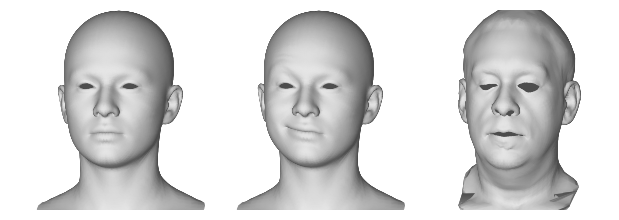

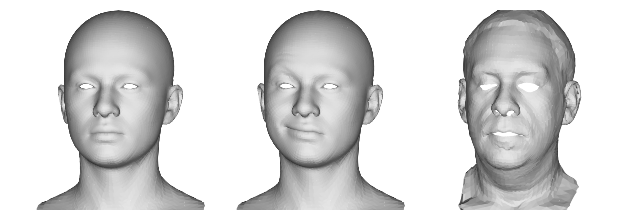

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
       0., 0.])

In [23]:
## full head
ict_face_model = ICT_face_model()
ict_tri = ict_face_model.get_mesh()

# ## flame
with open(f"/data/sihun/pca/VOCA-COMA/voca_templates.pkl",'rb') as f:
    mesh = pickle.load(f)
mesh_list = [idname for idname in mesh.keys() if idname!='face']
mesh_v = mesh[mesh_list[8]]
flame_tri=trimesh.Trimesh(vertices=mesh_v,faces=mesh['face'])
# flame_tri.vertices = flame_tri.vertices + np.array([0,0.15,0])

## biwi
# with open(f"/data/sihun/pca/BIWI_align_deci/templates_align_deci.pkl",'rb') as f:
#     mesh = pickle.load(f)
# mesh_list = [idname for idname in mesh.keys() if idname!='face']
# flame_tri = trimesh.load('/data/sihun/BIWI_align_deci/BIWI.ply')
# # flame_tri.vertices = mesh[mesh_list[12]]
# # mesh_v = mesh[mesh_list[1]]
# mesh_v = mesh[mesh_list[12]]
# m_align = np.load(f'{__abs_path__}/utils/biwi/align.npy')
# # flame_tri.vertices = np.concatenate((flame_tri.vertices,np.ones((flame_tri.vertices.shape[0],1))), axis=1) @ m_align.T
# flame_tri=trimesh.Trimesh(vertices=mesh_v, faces=mesh['face'])
# flame_tri.vertices = flame_tri.vertices + np.array([0,0.05,0])


# biwi_trimesh = trimesh.load(f'{__abs_path__}/test-mesh/BIWI.ply')
# with open(f'{__abs_path__}/test-mesh/biwi_templates.pkl', 'rb') as f:
#     mesh = pickle.load(f)

# mesh_list = [idname for idname in mesh.keys() if idname!='face']
# mesh_v = mesh[mesh_list[12]]
# flame_tri = trimesh.load('/data/sihun/BIWI_align_deci/BIWI.ply')

# m_align = np.load(f'{__abs_path__}/utils/biwi/align.npy')
# mesh_v = np.concatenate((mesh_v,np.ones((mesh_v.shape[0],1))), axis=1) @ m_align.T
# flame_tri.vertices = mesh_v
# # flame_tri=trimesh.Trimesh(vertices=mesh_v, faces=mesh['face'])

# flame_tri = trimesh.load('/source/sihun/NeuralFacialAnimation/test-mesh/malchom.obj')
# flame_tri.vertices = flame_tri.vertices - np.array([0, 1.5,0])



# flame_tri = trimesh.load('/source/sihun/NeuralFacialAnimation/test-mesh/head-reference.obj')
# flame_tri.vertices = flame_tri.vertices * 0.11
# flame_tri.vertices = flame_tri.vertices - np.array([0, 0.2,0])

## mf
with open(f"/data/sihun/pca/multiface_align/mf_templates.pkl",'rb') as f:
    mesh = pickle.load(f)
mesh_list = [idname for idname in mesh.keys() if idname!='face']
# mesh_v = mesh[mesh_list[-1]]
mesh_v = mesh[mesh_list[2]]
# mesh_v = mesh[mesh_list[-2]]
flame_tri=trimesh.Trimesh(vertices=mesh_v,faces=mesh['face'])


## flame
# flame_tri = trimesh.load(f'{__abs_path__}/test-mesh/flame_final_transformed.obj', process=False, maintain_order=True)
# flame_tri.vertices = flame_tri.vertices + np.array([0,0.1,0])
# flame_tri.vertices = flame_tri.vertices + np.array([0,0.2,0])
# flame_tri = trimesh.load(f'{__abs_path__}/test-mesh/biwi_M5.obj', process=False, maintain_order=True)
# flame_tri = trimesh.load(f'{__abs_path__}/test-mesh/biwi_M5_deci.obj', process=False, maintain_order=True)
print(flame_tri.vertices.shape)

## ICT random expression
bs_coeff = np.eye(53)[26]
# bs_coeff = np.eye(53)[51] + np.eye(53)[52] + np.eye(53)[26] * 0.6
# bs_coeff = np.eye(53)[23] + np.eye(53)[11] + np.eye(53)[46]
# bs_coeff = np.eye(53)[4] + np.eye(53)[8] + np.eye(53)[51]
bs_coeff = np.eye(53)[46] + np.eye(53)[5]
# bs_coeff = torch.from_numpy(bs_coeff)
id_coeff = np.random.rand(100)*1.5
vertices = (ict_tri.vertices + ict_face_model.get_exp_disp(bs_coeff)).squeeze()
src_mesh = ict_tri

# vertices = trimesh.load('../test-mesh/tgt_flame.obj').vertices
# vertices = trimesh.load('../test-mesh/tgt_mf_2.obj').vertices
# vertices = trimesh.load('../test-mesh/tgt_mf_2-3.obj').vertices
# src_mesh = flame_tri
# vertices, template, _ = ict_face_model.apply_coeffs(id_coeff, bs_coeff, return_all=True)#.squeeze()
# vertices = vertices.squeeze()
# src_mesh.vertices = template.squeeze()
tgt_mesh = flame_tri


print(ict_tri.vertices.shape)

M_SCALE = 0.68
rot_list=[[0,-10,0]]
SIZE=2
v_list=[ src_mesh.vertices * M_SCALE, vertices * M_SCALE, tgt_mesh.vertices * M_SCALE ]
f_list=[ src_mesh.faces, src_mesh.faces, tgt_mesh.faces ]

plot_mesh_gouraud(
    v_list, f_list, mesh_scale=1, orth_view=True,
    rot_list=rot_list*len(v_list), size=SIZE, mode='shade', 
    bg_black=False, logdir=f"_tmp/train", name=f"test", save=False
)
plot_image_array(
    v_list, f_list,
    rot_list=rot_list*len(v_list), size=SIZE, mode='shade', 
    bg_black=False, logdir=f"_tmp/train", name=f"test", save=False
)
bs_coeff

In [24]:
# import torch_geometric
# print(torch.from_numpy(src_mesh.vertices).shape)
# print(torch.from_numpy(src_mesh.faces).transpose(1,0).shape)
# gd = torch_geometric.utils.geodesic_distance(torch.from_numpy(src_mesh.vertices), torch.from_numpy(src_mesh.faces).transpose(1,0))
# # >>> pos = torch.tensor([[0.0, 0.0, 0.0], [2.0, 0.0, 0.0], [0.0, 2.0, 0.0], [2.0, 2.0, 0.0]])
# # >>> face = torch.tensor([[0, 0], [1, 2], [3, 3]])
# # >>> geodesic_distance(pos, face)
# # [[0, 1, 1, 1.4142135623730951],
# # [1, 0, 1.4142135623730951, 1],
# # [1, 1.4142135623730951, 0, 1],
# # [1.4142135623730951, 1, 1, 0]]

In [25]:
device=trainer.device
print(device)

sd_v = vertices
# print(sd_v.shape)
s_v_B_th = torch.from_numpy(src_mesh.vertices)[None].float().to(device)
s_n_B_th = torch.from_numpy(igl.per_vertex_normals(src_mesh.vertices, src_mesh.faces))[None].float().to(device)
sd_v_B_th = torch.from_numpy(sd_v)[None].float().to(device)
sd_n_B_th = torch.from_numpy(igl.per_vertex_normals(sd_v, src_mesh.faces))[None].float().to(device)

t_v_B_th = torch.from_numpy(tgt_mesh.vertices)[None].float().to(device)
t_n_B_th = torch.from_numpy(igl.per_vertex_normals(tgt_mesh.vertices, tgt_mesh.faces))[None].float().to(device)

pred_outputs, pred_source, exp_z_d, key_d, exp_z_s, key_s, key_weight = trainer.model.retarget(
    s_v_B_th, s_n_B_th, sd_v_B_th, sd_n_B_th, t_v_B_th, t_n_B_th, mesh_data=0, out_kw=True
)


cuda:0


In [26]:
print(key_weight.shape)
qwe = torch.count_nonzero(key_weight[0],dim=0)
print(qwe.min(), qwe.max(), qwe.shape)

print(torch.count_nonzero(qwe))
# key_weight[0][20]
# pred_outputs

torch.Size([1, 5223, 256])
tensor(0, device='cuda:0') tensor(819, device='cuda:0') torch.Size([256])
tensor(250, device='cuda:0')


	   source neutral   	|	  source expression  	|	   target neutral     	|	 pred target neutral 	|	 pred target expression 	|	 delta transferred


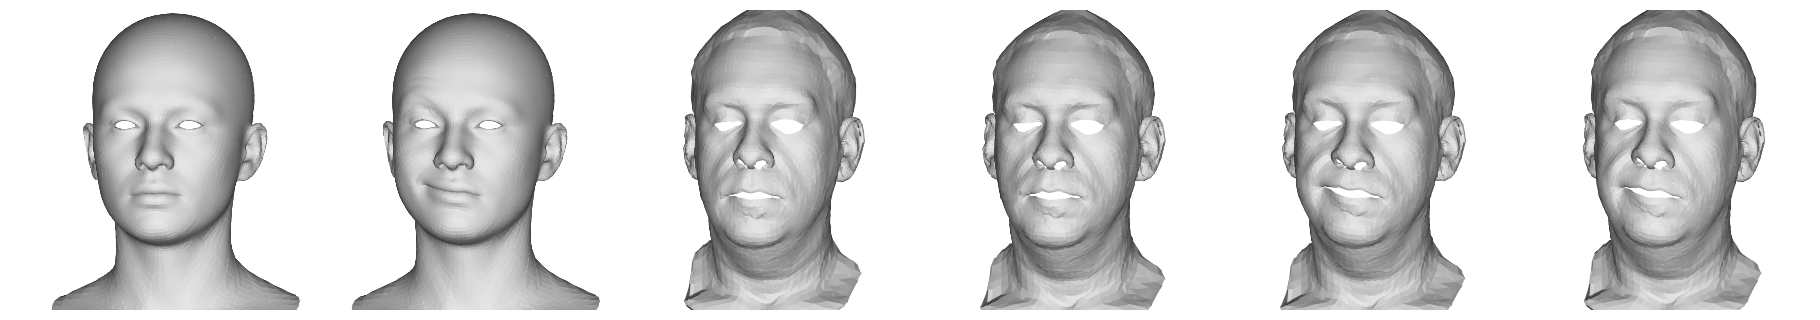

In [27]:
SIZE=3
M_SCALE=.67
SAVE=0
M_trns=np.array([0,0.,0])
rot_list=[[0,-10,0]]


# v_scale = np.linalg.norm(tgt_mesh.vertices - pred_source.detach().cpu().numpy()[0], axis=-1) + 1
# print(v_scale.min(), v_scale.max())

v_list=[ 
    src_mesh.vertices,
    vertices, 
    tgt_mesh.vertices, 
    pred_source.detach().cpu().numpy()[0], 
    pred_outputs.detach().cpu().numpy()[0],
    tgt_mesh.vertices + (pred_outputs.detach().cpu().numpy()[0]-pred_source.detach().cpu().numpy()[0]), 
]
# v_list=[ src_mesh.vertices, pred_source.detach().cpu().numpy()[0] ]
v_list = [v * M_SCALE + M_trns for v in v_list]
f_list=[ src_mesh.faces, src_mesh.faces, tgt_mesh.faces, tgt_mesh.faces, tgt_mesh.faces, tgt_mesh.faces ]
# f_list=[ src_mesh.faces, tgt_mesh.faces ]

print('\t   source neutral   \t|\t  source expression  \t|\t   target neutral     \t|\t pred target neutral \t|\t pred target expression \t|\t delta transferred')
# plot_mesh_gouraud(
#     v_list, f_list, mesh_scale=M_SCALE,
#     rot_list=rot_list*len(v_list), size=SIZE, mode='shade', 
#     bg_black=False, logdir=f"../_tmp", name=f"NBC-retarget-zoom", save=SAVE
# )
plot_image_array(
    v_list, f_list,
    rot_list=rot_list*len(v_list), size=SIZE, mode='shade', 
    bg_black=False, logdir=f"../_tmp", name=f"NBC-cage_example", save=SAVE
)

# v_list=[ vertices, pred_outputs.detach().cpu().numpy()[0]]

# v_list = [v * M_SCALE + M_trns for v in v_list]

# plot_image_array(
#     v_list, f_list,
#     rot_list=rot_list*len(v_list), size=SIZE, mode='shade', 
#     bg_black=False, logdir=f"../_tmp", name=f"NBC-cage_example", save=SAVE
# )

# M_SCALE=2.9
# M_trns=np.array([0.1, 1.9, 0])

# v_list=[ src_mesh.vertices, vertices, pred_source.detach().cpu().numpy()[0], pred_outputs.detach().cpu().numpy()[0]]
# v_list = [v * M_SCALE + M_trns for v in v_list]
# f_list=[ src_mesh.faces, src_mesh.faces, tgt_mesh.faces, tgt_mesh.faces ]

# print(' source neutral \t|\t source expression \t|\t target neutral \t|\t target expression')

# plot_image_array(
#     v_list, f_list,
#     rot_list=rot_list*len(v_list), size=SIZE, mode='shade', 
#     bg_black=False, logdir=f"../_tmp", name=f"NBC-retarget-zoom", save=SAVE
# )

In [28]:
# asdasd = trimesh.Trimesh(vertices=tgt_mesh.vertices + pred_outputs.detach().cpu().numpy()[0]-pred_source.detach().cpu().numpy()[0], faces = tgt_mesh.faces)
# _=asdasd.export('../test-mesh/tgt_mf_2-3.obj')

In [29]:
# import meshplot as mp

# v = pred_outputs.detach().cpu().numpy()[0]
# f = tgt_mesh.faces
# d = mp.subplot(v, f, c=v[:, 1], s=[2, 2, 0])
# d = mp.subplot(v, c=v[:, 1], s=[1, 2, 0], data=d, shading={"point_size": 0.03})
# # mp.subplot(v, c=np.random.rand(*v.shape), s=[1, 2, 1], data=d, shading={"point_size": 0.03})


In [30]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# Normalize vertices to homogeneous coordinates
def normalize_homogeneous(V):
    return np.concatenate([V, np.ones((V.shape[0], 1))], axis=1)

def transform(V, M):
    V_h = np.hstack([V, np.ones((V.shape[0], 1))])
    return (M @ V_h.T).T #[:, :3]
    
def vis_mesh_key_weight(
        verts, faces, key_weight, cage_idx,
        SIZE=4, yrot=0, cmap='magma', vmin=None, vmax=None, show_cbar=True,
        view_yrots=(0, 90, 180)
    ):
    """
    Args:
        verts: (N, 3)
        faces: (F, 3) int
        key_weight: (N, K)
        cage_idx: int
    """

    assert key_weight.shape[0] == verts.shape[0], \
        f"key_weight shape[0] ({key_weight.shape[0]}) != verts.shape[0] ({verts.shape[0]})"
    assert 0 <= cage_idx < key_weight.shape[1], \
        f"cage_idx {cage_idx} out of range [0, {key_weight.shape[1]-1}]"

    print("verts min/max:", verts.min(0), verts.max(0))

    Wv = key_weight[:, cage_idx]
    Wf = Wv[faces].mean(axis=1)

    if vmin is None: vmin = float(Wf.min())
    if vmax is None: vmax = float(Wf.max())
    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap_fn = plt.get_cmap(cmap)

    V = normalize_homogeneous(verts)
    
    view  = translate(0, 0, -3.5)
    proj  = perspective(55, 1.0, 1.0, 100.0)
#     proj = ortho(-1, 1, -1, 1, 1, 100) # Use ortho instead of perspective
    MV   = proj @ view
    
    
    
    num_views = len(view_yrots)
    fig = plt.figure(figsize=(SIZE* num_views, SIZE ))
    
    for j, add_rot in enumerate(view_yrots):
        model = yrotate(yrot+add_rot)
        
        #model = yrotate(yrot)
        V_mu = np.median(V, axis=0)
        V_model = (V-V_mu) @ model.T + V_mu
        
        #MVP   = proj @ view @ model
        V_proj = V_model @ MV.T
        V_proj  = V_proj[:, :3] / V_proj[:, 3:4]  # (N,3), -1~1
    
        VF = V_proj[faces]
        T = VF[:, :, :2]
        Z = -VF[:, :, 2].mean(1)
        order = np.argsort(Z)
    
        T_sorted  = T[order]
        W_sorted  = Wf[order]
    
        C = cmap_fn(norm(W_sorted))  # (F,4)
    
        #fig = plt.figure(figsize=(SIZE, SIZE))
        # ax = fig.add_axes([0, 0, 1, 1], xlim=[-1, 1], ylim=[-1, 1], aspect=1, frameon=False)
        # coll = PolyCollection(T_sorted, closed=True, linewidth=0.2, facecolor=C, edgecolor=C)
        # ax.add_collection(coll)
        # ax.set_xticks([]); ax.set_yticks([])
        # ax.set_xlim(-1, 1); ax.set_ylim(-1, 1)
        ax = fig.add_axes([j / num_views, 0, 1 / num_views, 1],
                          xlim=[-1, 1], ylim=[-1, 1], aspect=1, frameon=False)

        coll = PolyCollection(T_sorted, closed=True, linewidth=0.1,
                              facecolor=C, edgecolor=C)
        ax.add_collection(coll)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_xlim(-1, 1); ax.set_ylim(-1, 1)
        # ax.set_title(f"y={yrot + add_rot}° ({mode})", fontsize=10)
    
        if show_cbar:
            # colorbar
            sm = ScalarMappable(norm=norm, cmap=cmap_fn)
            sm.set_array([])
            cbar = plt.colorbar(sm, ax=ax, fraction=0.02, pad=0.02)
            cbar.set_label(f"key_weight[:, {cage_idx}]")
    
        plt.title(f"Cage vertex {cage_idx} weight")
    plt.show()

def vis_mesh_all_cage_weights(
    verts, faces, key_weight,
    cage_indices=None,          # 시각화할 케이지 인덱스 리스트 (None이면 전체)
    mode='argmax',              # 'argmax' | 'blend'
    SIZE=4, yrot=0,
    base_cmap='tab20',          # 범주형 팔레트(케이지별 색)
    show_legend=False,
    mesh_scale=1.0,
    mesh_trans=np.array([0,0.0,0]),
    light_dir=np.array([0,0,1]),
    view_yrots=(0, 90, 180)
):
    """
    Args:
        verts: (N, 3)
        faces: (F, 3) int
        key_weight: (N, K)  # mesh vertex x cage vertex
        cage_indices: list[int] or None
        base_cmap: matplotlib colormap name ('tab20', 'tab20b', ...)
    """
    verts  = np.asarray(verts) * mesh_scale + mesh_trans
    faces  = np.asarray(faces, dtype=int)
    W_full = np.asarray(key_weight)
    N, K = W_full.shape
    assert verts.shape[0] == N, f"verts ({verts.shape[0]}) vs key_weight rows ({N}) mismatch"

    if cage_indices is None:
        cage_indices = list(range(K))
    else:
        cage_indices = list(cage_indices)
        assert all(0 <= i < K for i in cage_indices), "cage_indices out of range"

    M = len(cage_indices)

    ## color palete
    cmap = plt.get_cmap(base_cmap, max(M, 3))  # least 3
    
    # if M <= cmap.N:
    if False:
        base_colors = np.asarray([cmap(i) for i in range(M)])  # (M,4)
    else:
        cmap_wide = plt.get_cmap('nipy_spectral')
        # cmap_wide = plt.get_cmap('gist_rainbow')
        # cmap_wide = plt.get_cmap('rainbow') ##
        # cmap_wide = plt.get_cmap('jet')
        # cmap_wide = plt.get_cmap('cubehelix')
        # cmap_wide = plt.get_cmap('turbo')
        # cmap_wide = plt.get_cmap('gist_ncar')
        base_colors = np.asarray([cmap_wide(i/(M-1)) for i in range(M)])
        # base_colors = np.asarray([cmap_wide(i/(M)) for i in range(M)])

    # (N, M) 선택 케이지 weight
    W_sel = W_full[:, cage_indices]  # (N, M)
    Wf_all = W_sel[faces].mean(axis=1)

    #V = normalize_homogeneous(verts)
    #V = verts #- verts.mean(0, keepdims=True)
    V = normalize_homogeneous(verts)
    view = translate(0, 0, -4.5)
    #proj = perspective(45, 1.0, 1.0, 100.0)
    proj  = ortho(-1, 1, -1, 1, 1, 100) # Use ortho instead of perspective
    MV   = proj @ view
    
    num_views = len(view_yrots)
    fig = plt.figure(figsize=(SIZE* num_views, SIZE ))
    
    for j, add_rot in enumerate(view_yrots):
        model = yrotate(yrot+add_rot)
        
        #V_clip = V @ MVP.T
        # V_clip = transform(V, MVP)
        C = calc_face_norm(verts, faces) @ model[:3,:3].T
        
        # V_mu = np.median(V, axis=0)
        V_mu = np.array([[0, 0, -0.45, 0]])
        V_model = (V - V_mu) @ model.T + V_mu
        #V_model = V_model - np.mean(V_model, axis=0) + V_mu

        V_proj = V_model @ MV.T
        V_ndc  = V_proj[:, :3] / V_proj[:, 3:4]  # (N,3), -1~1
        # V_ndc  = V_clip[:, :3] / V_clip[:, 3:4]
    
        VF = V_ndc[faces]        # (F, 3, 3)
        T  = VF[:, :, :2]        # (F, 3, 2)
        Z  = -VF[:, :, 2].mean(1)
        order = np.argsort(Z)
    
        T_sorted = T[order]
        W_sorted = Wf_all[order]
        C_sorted = C[order]
        NI = np.argwhere(C_sorted[:,2] > 0).squeeze()

        T_sorted = T_sorted[NI]
        W_sorted = W_sorted[NI]
        C_sorted = C_sorted[NI]
        
        C_sorted = (C_sorted @ light_dir)[:,np.newaxis].repeat(3, axis=-1)
        C_sorted = C_sorted*0.7+0.2
    
        if mode == 'argmax':
            labels = np.argmax(W_sorted, axis=-1)  # (F,)
            face_colors = base_colors[labels]     # (F,4)
            face_colors[:,:3] = face_colors[:,:3] *0.7 + C_sorted *.3
            print(face_colors.shape)
        elif mode == 'blend':
            # sum_row = W_sorted.sum(axis=1, keepdims=True) + 1e-12
            # Wn = W_sorted / sum_row
            Wn = W_sorted #/ W_sorted.max()
            # print(Wn.min(), Wn.max())
            rgb = Wn @ base_colors[:, :3]    # (F,3)
            # rgb = rgb * 2
            # print(rgb.min(), rgb.max())
            rgb = (rgb-rgb.min(0)) / (rgb.max(0) - rgb.min(0))
            print(Wn.shape, T_sorted.shape, rgb.shape, C_sorted.shape)
            rgb = rgb *0.7 + C_sorted *.3
            rgb = np.clip(rgb, 0, 1)
            alpha = np.ones((rgb.shape[0], 1))
            face_colors = np.concatenate([rgb, alpha], axis=1)  # (F,4)
        else:
            raise ValueError("mode must be 'argmax' or 'blend'")
    
        ### PLOT
        #fig = plt.figure(figsize=(SIZE, SIZE))
        # ax = fig.add_axes([0, 0, 1, 1], xlim=[-1, 1], ylim=[-1, 1], aspect=1, frameon=False)
        ax = fig.add_axes([j / num_views, 0, 1 / num_views, 1],
                          xlim=[-1, 1], ylim=[-1, 1], aspect=1, frameon=False)

        coll = PolyCollection(T_sorted, closed=True, linewidth=0.1,
                              facecolor=face_colors, edgecolor='black')
        ax.add_collection(coll)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_xlim(-1, 1); ax.set_ylim(-1, 1)
        ax.set_title(f"y={yrot + add_rot}° ({mode})", fontsize=10)
        # plt.title(f"All cage weights ({mode})")
    
        if show_legend:
            handles = []
            for i, ci in enumerate(cage_indices):
                handles.append(mpatches.Patch(color=base_colors[i], label=f"cage {ci}"))
            
            if len(handles) <= 12:
                ax.legend(handles=handles, loc='upper right', fontsize=8)
            else:
                ax.legend(handles=handles, bbox_to_anchor=(1.02, 1.0), loc='upper left',
                          borderaxespad=0., fontsize=7, ncol=1)

    plt.show()

In [31]:
print(key_weight.min(), key_weight.max())

torch.count_nonzero(key_weight[0].sum(0))
# torch.nonzero(key_weight[0].sum(0))

tensor(0., device='cuda:0') tensor(0.7039, device='cuda:0')


tensor(250, device='cuda:0')

(4939, 256) (4939, 3, 2) (4939, 3) (4939, 3)
(3596, 256) (3596, 3, 2) (3596, 3) (3596, 3)
(1971, 256) (1971, 3, 2) (1971, 3) (1971, 3)


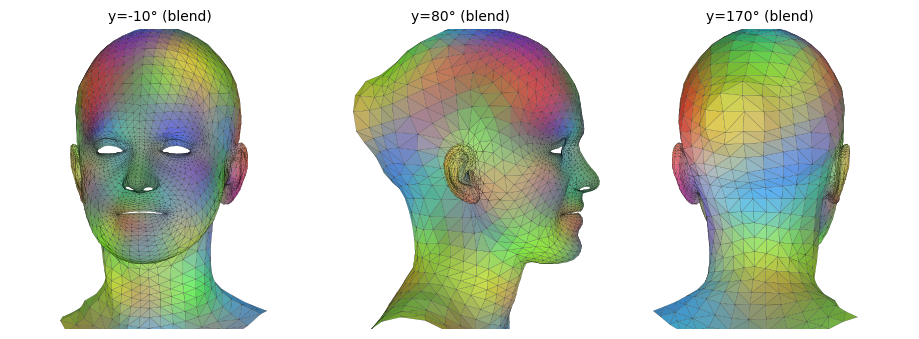

(4939, 4)
(3596, 4)
(1971, 4)


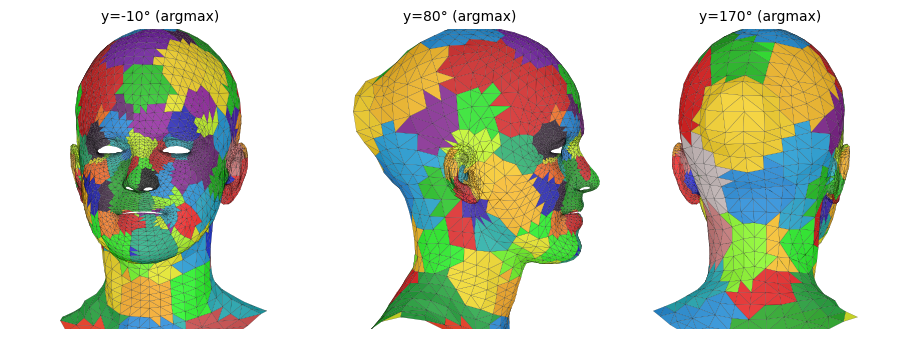

In [10]:
size = 3
vis_mesh_all_cage_weights(
    tgt_mesh.vertices, tgt_mesh.faces,
    key_weight[0].detach().cpu().numpy(), mode='blend', mesh_scale=0.67, SIZE=size, yrot=-10)
vis_mesh_all_cage_weights(
    tgt_mesh.vertices, tgt_mesh.faces,
    key_weight[0].detach().cpu().numpy(), mode='argmax', mesh_scale=0.67, SIZE=size, yrot=-10)

(8258, 256) (8258, 3, 2) (8258, 3) (8258, 3)
(5475, 256) (5475, 3, 2) (5475, 3) (5475, 3)
(2020, 256) (2020, 3, 2) (2020, 3) (2020, 3)


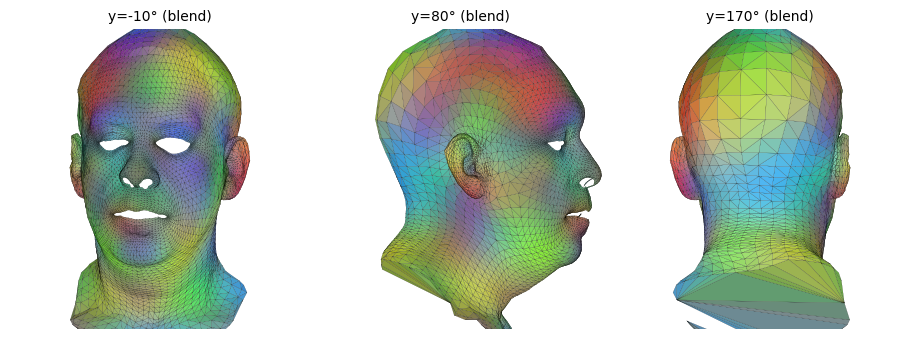

(8258, 4)
(5475, 4)
(2020, 4)


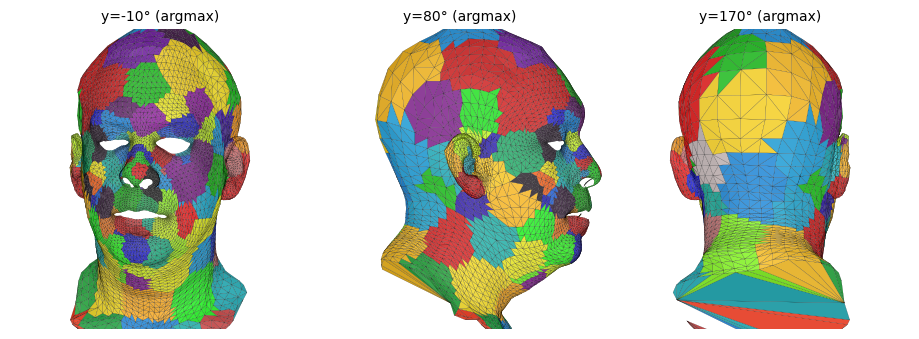

In [32]:
# for NC in [77,18,202,312]:
# for NC in [459,477,202]:
# for NC in range(460,480):
#     print(key_d.squeeze()[NC])
# for NC in [10,20,92]:
#     vis_mesh_key_weight(
#         pred_source[0].detach().cpu().numpy(), tgt_mesh.faces, key_weight[0].detach().cpu().numpy(), 
#         cage_idx=NC, 
#         SIZE=2, yrot=0, cmap='viridis', show_cbar=True, 
#         view_yrots=(-10,)
#     )
size = 3
vis_mesh_all_cage_weights(
    tgt_mesh.vertices, tgt_mesh.faces,
    key_weight[0].detach().cpu().numpy(), mode='blend', mesh_scale=0.67, SIZE=size, yrot=-10)
vis_mesh_all_cage_weights(
    tgt_mesh.vertices, tgt_mesh.faces,
    key_weight[0].detach().cpu().numpy(), mode='argmax', mesh_scale=0.67, SIZE=size, yrot=-10)

In [33]:
def check_ray_triangle_intersection(ray_origins, ray_direction, triangle, epsilon=1e-6):
    """
    Optimized to work for:
        >1 ray_origins
        1 ray_direction multiplied to match the dimension of ray_origins
        1 triangle

    Based on: Answer by BrunoLevy at
    https://stackoverflow.com/questions/42740765/intersection-between-line-and-triangle-in-3d
    Thank you!

    Parameters
    ----------
    ray_origin : torch.Tensor, (n_rays, n_dimensions), (x, 3)
    ray_directions : torch.Tensor, (n_rays, n_dimensions), (1, x)
    triangle : torch.Tensor, (n_points, n_dimensions), (3, 3)

    Return
    ------
    intersection : boolean (n_rays,)

    Test
    ----
    triangle = torch.Tensor([[0., 0., 0.],
                             [1., 0., 0.],
                             [0., 1., 0.],
                            ]).to(device)

    ray_origins = torch.Tensor([[0.5, 0.25, 0.25],
                                [5.0, 0.25, 0.25],
                               ]).to(device)

    ray_origins = torch.rand((10000, 3)).to(device)

    ray_direction = torch.Tensor([[0., 0., -10.],]).to(device)
    #ray_direction = torch.Tensor([[0., 0., 10.],]).to(device)

    ray_direction = ray_directions.repeat(ray_origins.shape[0], 1)

    check_ray_triangle_intersection(ray_origins, ray_direction, triangle)
    """

    E1 = triangle[1] - triangle[0] #vector of edge 1 on triangle
    E2 = triangle[2] - triangle[0] #vector of edge 2 on triangle
    N = torch.cross(E1, E2) # normal to E1 and E2

    invdet = 1. / -torch.einsum('ji, i -> j', ray_direction, N) # inverse determinant

    A0 = ray_origins - triangle[0]
    # print('A0.shape: ', A0.shape)
    # print('ray_direction.shape: ', ray_direction.shape)
    DA0 = torch.cross(A0, ray_direction)

    u = torch.einsum('ji, i -> j', DA0, E2) * invdet
    v = -torch.einsum('ji, i -> j', DA0, E1) * invdet
    t = torch.einsum('ji, i -> j', A0, N) * invdet

    intersection = (t >= 0.0) * (u >= 0.0) * (v >= 0.0) * ((u + v) <= 1.0)

    return intersection

In [34]:
# torch.from_numpy(tgt_mesh.vertices),  key_s[NNN]
print(key_s[0].shape)
print(tgt_mesh.vertices[tgt_mesh.faces].shape)

ray_direction = torch.eye(3).to(device)[0]
ray_direction = ray_direction.repeat(key_s[0].shape[0], 1)

print(ray_direction.shape)
for tri in tgt_mesh.vertices[tgt_mesh.faces]:
# check_ray_triangle_intersection(ray_origins, ray_direction, triangle, epsilon=1e-6)
    tri = torch.from_numpy(tri).float().to(device)#.unsqueeze(1)
    print(check_ray_triangle_intersection(key_s[0], ray_direction, tri, epsilon=1e-6).all())
    break

torch.Size([256, 3])
(10278, 3, 3)
torch.Size([256, 3])
tensor(False, device='cuda:0')


In [35]:
from utils.matplotlib_rnd import xrotate, yrotate, zrotate
import matplotlib.cm as cm

def draw_mesh_and_key_v(template_v_th, key_v, key_weight, faces, only_nz=False, show_numbers=False):
    mesh_v = template_v_th.detach().cpu().numpy()
    
    if only_nz:
        args_nz = torch.nonzero(key_weight.sum(0)).squeeze()
        print(key_v.shape)
        print(args_nz.shape)
        foo=torch.zeros(key_v.shape[0], dtype=bool)
        foo[args_nz]=1
        args_nz=foo
        points = key_v[args_nz].detach().cpu().numpy()
        print(points.shape)
    else:
        points = key_v.detach().cpu().numpy()

    fig = plt.figure(figsize=(15, 7))
    ax = fig.add_subplot(131, projection='3d')

    colors = cm.rainbow(np.linspace(0, 1, points.shape[0]))
    # colors = 'red'
    alpha_=0.6

    lim_x = max(mesh_v[:,0].max(), points[:, 0].max())-min(mesh_v[:,0].min(), points[:, 0].min())
    lim_y = max(mesh_v[:,1].max(), points[:, 1].max())-min(mesh_v[:,1].min(), points[:, 1].min())
    lim_z = max(mesh_v[:,2].max(), points[:, 2].max())-min(mesh_v[:,2].min(), points[:, 2].min())
    # print(lim_x, lim_y, lim_z)
    
    ax.plot_trisurf(mesh_v[:, 0], mesh_v[:, 1], mesh_v[:, 2],
                    triangles=faces, alpha=alpha_, color='lightgrey', linewidth=0.1)

    #ax.scatter(points[:, 0], points[:, 1], points[:, 2], color='r', s=1)
    if show_numbers:
        for i in range(len(points)):
            ax.scatter(points[i,0], points[i,1], points[i,2], marker=f'${i}$', s=100,color=colors[i]) # s controls marker size
    else:
        ax.scatter(points[:, 0], points[:, 1], points[:, 2], color=colors, s=5)

    ax.view_init(elev=90, azim=-90)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_box_aspect([lim_x, lim_y, lim_z])

    
    ax = fig.add_subplot(132, projection='3d')

    mat = yrotate(90)[:3,:3]
    mesh_v2 = mesh_v @ mat
    points_2 = points @ mat
    ax.plot_trisurf(mesh_v2[:, 0], mesh_v2[:, 1], mesh_v2[:, 2],
                    triangles=faces, alpha=alpha_, color='lightgrey', linewidth=0.1)

    # ax.scatter(points_2[:, 0], points_2[:, 1], points_2[:, 2], color='r', s=1)
    
    if show_numbers:
        for i in range(len(points)):
            ax.scatter(points_2[i,0], points_2[i,1], points_2[i,2], marker=f'${i}$', s=100,color=colors[i]) # s controls marker size
    else:
        ax.scatter(points_2[:, 0], points_2[:, 1], points_2[:, 2], color=colors, s=5)
        
    ax.view_init(elev=90, azim=-90)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_box_aspect([lim_x, lim_y, lim_z])
    
    
    ax = fig.add_subplot(133, projection='3d')

    # mesh_v = mesh_v @ zrotate(-90)[:3,:3] @ yrotate(-90)[:3,:3]
    # mat = yrotate(-30)[:3,:3]
    mat = yrotate(180)[:3,:3]
    mesh_v3 = mesh_v @ mat
    points_3 = points @ mat
    ax.plot_trisurf(mesh_v3[:, 0], mesh_v3[:, 1], mesh_v3[:, 2],
                    triangles=faces, alpha=alpha_, color='lightgrey', linewidth=0.1)

    #Cs = np.random.rand(points.shape[0])
    #ax.scatter(points_3[:, 0], points_3[:, 1], points_3[:, 2], c=Cs, s=2)
    if show_numbers:
        for i in range(len(points)):
            ax.scatter(points_3[i,0], points_3[i,1], points_3[i,2], marker=f'${i}$', s=100,color=colors[i]) # s controls marker size
    else:
        ax.scatter(points_3[:, 0], points_3[:, 1], points_3[:, 2], color=colors, s=5)
        
    ax.view_init(elev=90, azim=-90)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_box_aspect([lim_x, lim_y, lim_z])
    plt.tight_layout()
    
    plt.show()

torch.Size([3]) torch.Size([5223])
num0 tensor(0.2799)
num1 tensor(0.2799)
num2 tensor(0.0207)
tensor(158)
tensor(158)
verts min/max: [-0.9075414 -1.824955  -1.461868 ] [0.9143374 1.5220547 0.7730596]


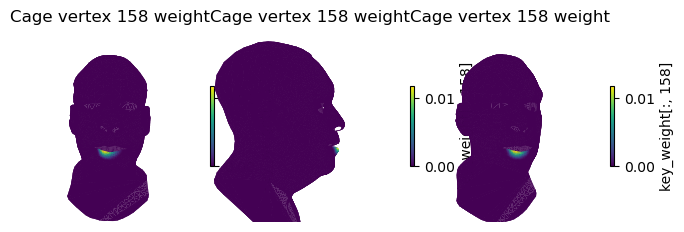

cage vertex:  tensor(158) tensor([[-0.0369, -0.2355,  0.5632]], device='cuda:0')


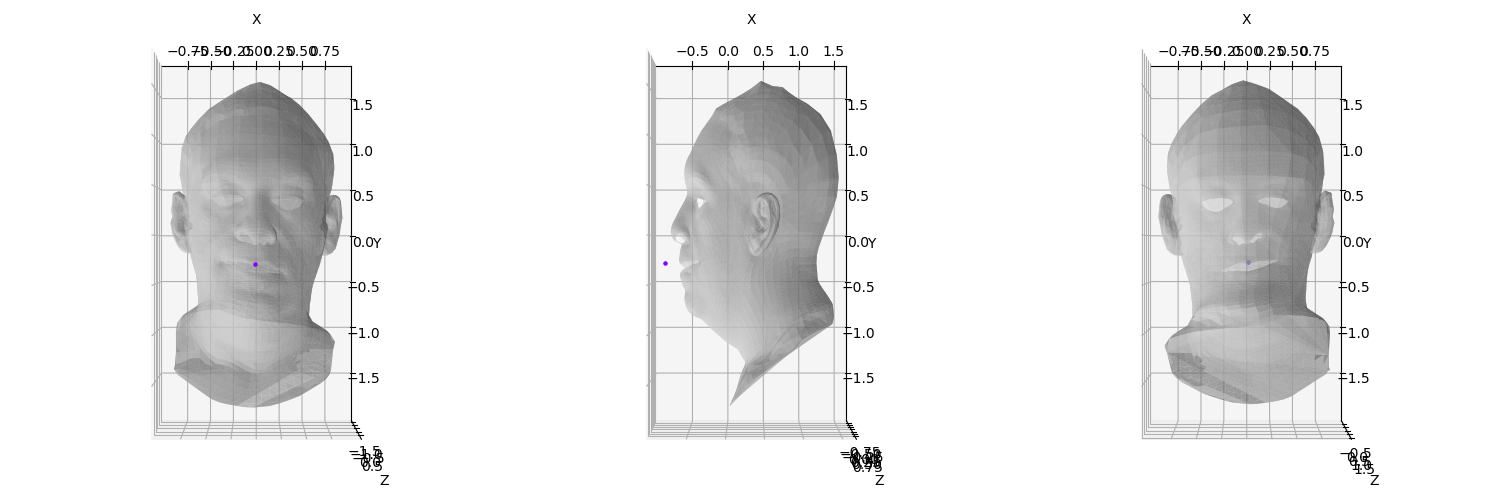

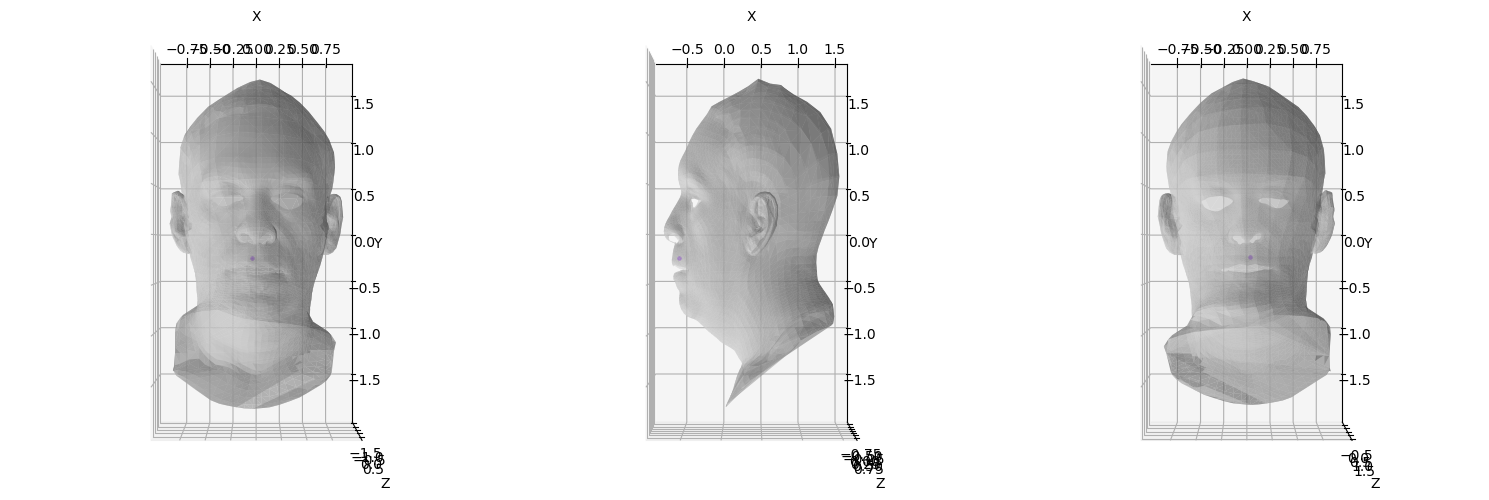

In [119]:
NNN=0
print(key_s[0,0].shape, key_weight[0,:,0].shape)
# NUM=torch.argmax(torch.linalg.norm(key_d[0] - key_s[0], dim=1))
d_len = torch.linalg.norm(key_d[0] - key_s[0], dim=1).detach().cpu()
NUMs = torch.argsort(d_len).flip(-1)
arg_list = torch.arange(key_s[0].shape[0])#[NUMs.detach().cpu()]
# print(d_len[NUMs])
# print(arg_list)


SLC=18
print('num0',d_len[NUMs][SLC])
print('num1',d_len[arg_list[NUMs]][SLC])
print('num2',d_len[NUMs[NUMs]][SLC])
print(arg_list[NUMs][SLC])
# print(NUMs[NUMs])
# print(arg_list)
# NUM=NUMs[NUMs][0]
NUM=arg_list[NUMs][SLC]

# mask=torch.ones(key_s[0].shape[0], dtype=bool)
# mask[NUM]=False
# NUM=torch.argmax(torch.linalg.norm(key_d[0,mask] - key_s[0,mask], dim=1))
print(NUM)
# NUM=16
# NUM=20
# NUM=58
# NUM=90
# NUM=24
# NUM=72

vis_mesh_key_weight(
    pred_source[0].detach().cpu().numpy(), tgt_mesh.faces, key_weight[0].detach().cpu().numpy(), 
    cage_idx=NUM, 
    SIZE=2, yrot=0, cmap='viridis', show_cbar=True, 
    view_yrots=(0,90, 20)
)

print('cage vertex: ', NUM, key_s[0,NUM][None])

# draw_mesh_and_key_v(pred_source[NNN],  key_s[0,NUM][None], key_weight[0,:,NUM][:,None], tgt_mesh.faces)
# draw_mesh_and_key_v(pred_outputs[NNN], key_d[0,NUM][None], key_weight[0,:,NUM][:,None], tgt_mesh.faces)
deformed = tgt_mesh.vertices + (pred_outputs.detach().cpu().numpy()[0]-pred_source.detach().cpu().numpy()[0])
draw_mesh_and_key_v(torch.from_numpy(deformed),           key_d[0,NUM][None], key_weight[0,:,NUM][:,None], tgt_mesh.faces)
draw_mesh_and_key_v(torch.from_numpy(tgt_mesh.vertices),  key_s[0,NUM][None], key_weight[0,:,NUM][:,None], tgt_mesh.faces)


num0 tensor(0.3325)
num1 tensor(0.3325)


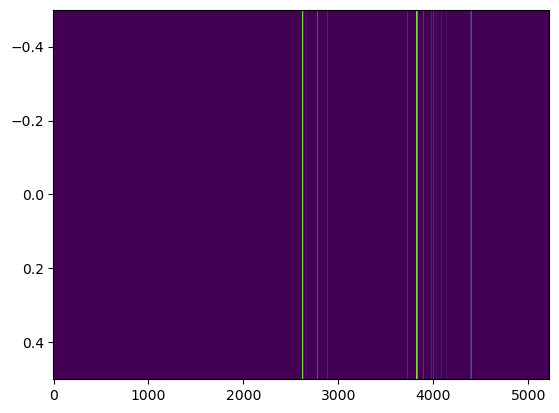

In [115]:

print('num0',d_len[NUMs][SLC])
print('num1',d_len[arg_list[NUMs]][SLC])

plt.imshow(key_weight[0,:,NUM].detach().cpu().numpy()[None], interpolation='nearest', aspect='auto')

torch.Size([256, 3])
torch.Size([250])
(250, 3)


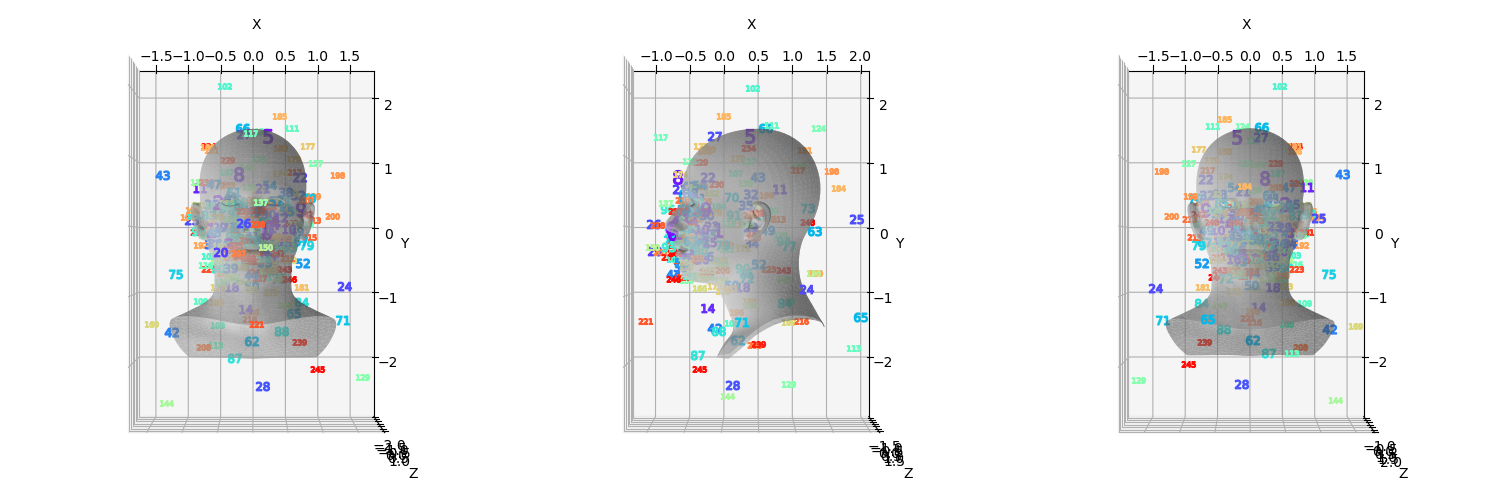

torch.Size([256, 3])
torch.Size([250])
(250, 3)


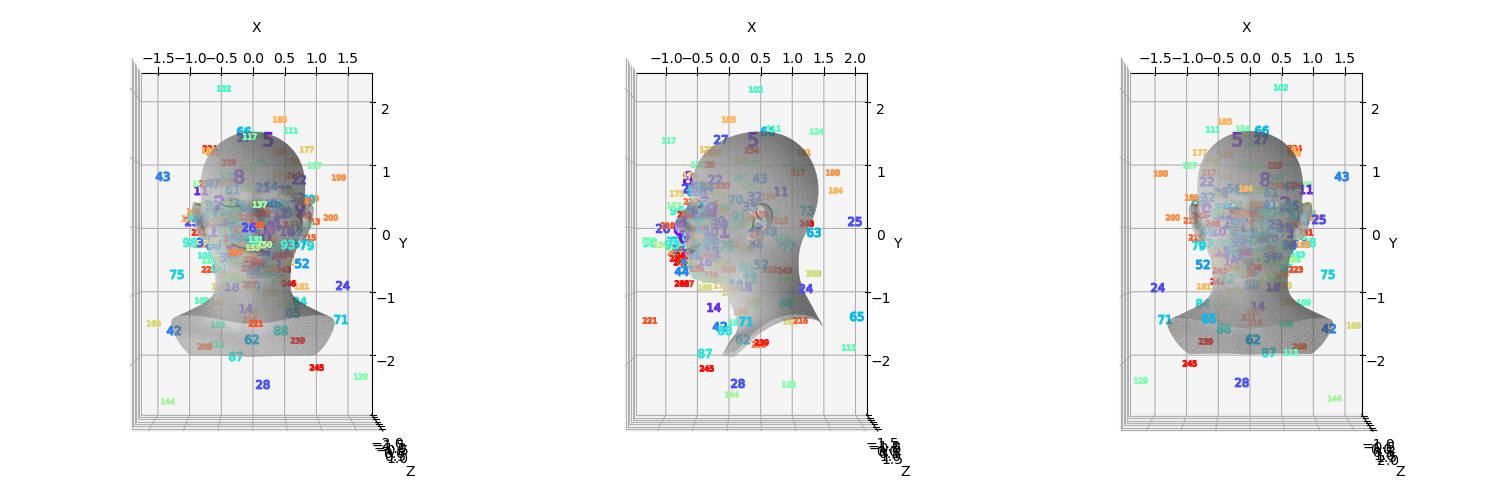

In [37]:
NNN=0

# draw_mesh_and_key_v(pred_source[NNN],  key_s[NNN], key_weight[NNN], tgt_mesh.faces)
# draw_mesh_and_key_v(pred_outputs[NNN], key_d[NNN], key_weight[NNN], tgt_mesh.faces)
# draw_mesh_and_key_v(torch.from_numpy(src_mesh.vertices), key_s[NNN], key_weight[NNN], src_mesh.faces)
# draw_mesh_and_key_v(torch.from_numpy(vertices),          key_d[NNN], key_weight[NNN], src_mesh.faces)
# draw_mesh_and_key_v(pred_outputs[NNN], key_d[NNN], key_weight[NNN], tgt_mesh.faces, True)
# draw_mesh_and_key_v(pred_source[NNN],  key_s[NNN], key_weight[NNN], tgt_mesh.faces, True)
draw_mesh_and_key_v(torch.from_numpy(src_mesh.vertices),  key_s[NNN], key_weight[NNN], src_mesh.faces, True, show_numbers=True)
draw_mesh_and_key_v(torch.from_numpy(vertices),           key_d[NNN], key_weight[NNN], src_mesh.faces, True, show_numbers=True)

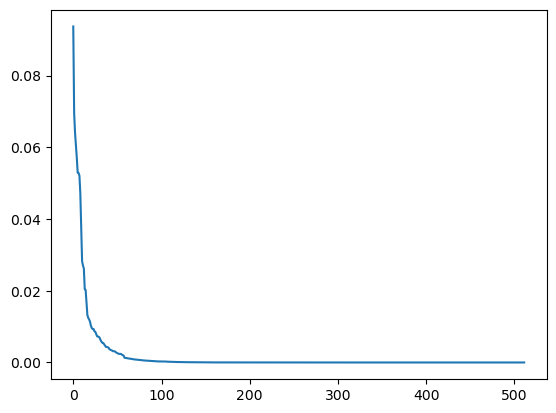

torch.Size([1, 5223, 512])

In [18]:
import scipy
# np.sort(key_weight[0,:,].detach().cpu().numpy())

##################
asd = key_d[0].detach().cpu().numpy()
asd = np.linalg.norm(asd, axis=-1)
##################


# asd = np.sort(np.linalg.norm(asd, axis=-1))
asd = np.sort(asd)
asd = asd.max() - asd

asd = scipy.special.softmax(asd*asd, axis=0)
plt.plot(asd)
plt.show()
# plt.plot(np.sort(key_weight[0][1].detach().cpu().numpy()))
# plt.show()
# plt.plot(np.sort(key_weight[0][2].detach().cpu().numpy()))
# plt.show()
key_weight.shape

torch.Size([96, 3])
torch.Size([3525, 3])
torch.Size([96, 3525])
tensor([[5.0207, 5.0195, 5.0029,  ..., 5.4517, 5.6036, 5.6243],
        [5.0018, 5.0295, 5.0205,  ..., 6.3067, 6.2974, 6.3532],
        [4.9368, 4.9319, 4.9210,  ..., 5.5071, 5.5481, 5.5719],
        ...,
        [2.8134, 2.8481, 2.8398,  ..., 4.0780, 4.1075, 4.1635],
        [2.8656, 2.8522, 2.8465,  ..., 2.6146, 2.7027, 2.7025],
        [4.3506, 4.3742, 4.3537,  ..., 4.8940, 5.1613, 5.1910]],
       device='cuda:0')
20.0
torch.Size([96, 3525])
tensor(1.0000, device='cuda:0') tensor(0., device='cuda:0')
tensor(3525, device='cuda:0')
0.7518897 3.3955005e-20


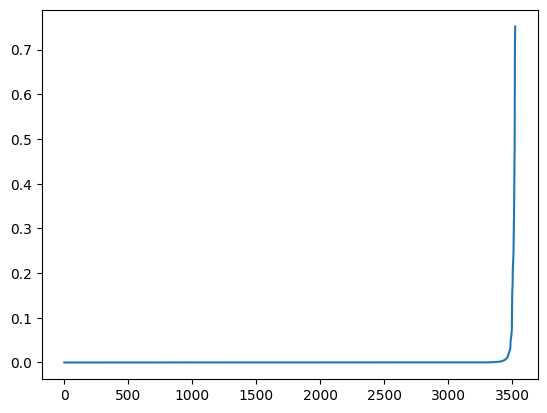

torch.Size([1, 3525, 96])

In [136]:
import scipy
NNN=0
asdasd = pred_source[NNN].detach()#.cpu().numpy()
asd = key_d[NNN].detach()#.cpu().numpy()
# asd = pred_source[0,0].detach().cpu().numpy()

print(asd.shape)
print(asdasd.shape)
asd = asdasd.repeat(asd.shape[0],1,1) - asd[:,None]
# asd =  np.sort(key_weight[0,:,1].detach().cpu().numpy())

##################
# asd = key_d[0].detach().cpu().numpy()
asd = torch.linalg.norm(asd, axis=-1)
##################
print(asd.shape)

# asd = np.sort(np.linalg.norm(asd, axis=-1))
asd = asd.max(0).values - asd
print(asd)
# asd = torch.sort(asd)

asas=1/0.05
print(asas)
asd = torch.nn.functional.softmax(asd * asas, dim=0)
print(asd.shape)
print(asd.max(), asd.min())
SSSS=0

print(torch.count_nonzero(asd[SSSS]))

asd = np.sort(asd.detach().cpu().numpy())

print(asd[SSSS].max(), asd[SSSS].min())
plt.plot(asd[SSSS])
plt.show()
# plt.plot(np.sort(key_weight[0][1].detach().cpu().numpy()))
# plt.show()
# plt.plot(np.sort(key_weight[0][2].detach().cpu().numpy()))
# plt.show()
key_weight.shape

torch.Size([1, 1, 96, 3])
torch.Size([1, 3525, 96, 3])
torch.Size([1, 3525, 96, 3])
torch.Size([1, 3525, 96])
torch.Size([1, 3525, 96])
2 torch.Size([1, 3525])
1 torch.Size([1, 96])
tensor([[[0.3333, 0.4406, 0.3646,  ..., 0.2586, 0.1999, 0.3677],
         [0.3224, 0.4412, 0.3534,  ..., 0.2604, 0.1917, 0.3671],
         [0.3179, 0.4400, 0.3514,  ..., 0.2598, 0.1916, 0.3630],
         ...,
         [0.4541, 0.8339, 0.5253,  ..., 0.4763, 0.1193, 0.4798],
         [0.4634, 0.7875, 0.4930,  ..., 0.4572, 0.1107, 0.5175],
         [0.4661, 0.8016, 0.4966,  ..., 0.4653, 0.1077, 0.5218]]],
       device='cuda:0')
100.0
torch.Size([1, 3525, 96])
tensor(0.9847, device='cuda:0') tensor(2.2602e-40, device='cuda:0')
torch.Size([1, 3525, 1, 3]) torch.Size([1, 1, 1, 3])
1 tensor(2.4732, device='cuda:0') tensor(0.3301, device='cuda:0')
torch.Size([1, 3525, 1])
11 tensor(1., device='cuda:0') tensor(0.1335, device='cuda:0')
111 tensor(0.8665, device='cuda:0') tensor(0., device='cuda:0')


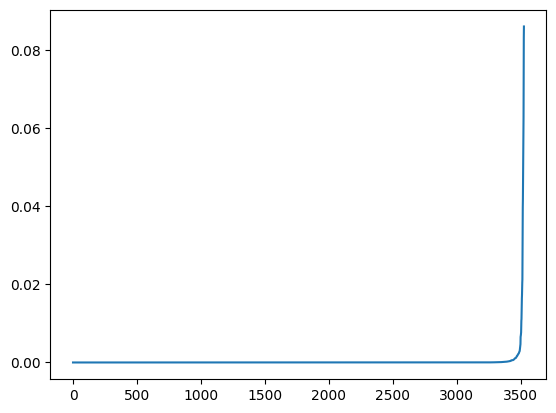

torch.Size([1, 3525, 96])

In [264]:
import scipy
NNN=0
asdasd = pred_source.detach()#.cpu().numpy()
asd = key_d.detach()#.cpu().numpy()
# asd = pred_source[0,0].detach().cpu().numpy()

print(asd[:,None].shape)
print(asdasd[:,:,None].repeat(1,1,asd.shape[1],1).shape)
asd = asdasd[:,:,None].repeat(1,1,asd.shape[1],1) - asd[:,None]
# asd =  np.sort(key_weight[0,:,1].detach().cpu().numpy())

print(asd.shape)
##################
# asd = key_d[0].detach().cpu().numpy()
asd = torch.linalg.norm(asd, dim=-1)
print(asd.shape)
# asd = torch.linalg.norm(asd, ord='inf')
##################
print(asd.shape)

# asd = np.sort(np.linalg.norm(asd, axis=-1))
print('2',asd.max(2).values.shape)
print('1',asd.max(1).values.shape)
# asd = asd.max(2).values.unsqueeze(-1) - asd
asd = asd / asd.max(1).values.unsqueeze(-2)
asd = 1 - asd
print(asd)
# asd = torch.sort(asd)

asas=1/0.01
print(asas)
print(asd.shape)
# asd = torch.nn.functional.relu(asd**2)
# asd = torch.exp(asd)
asd = torch.nn.functional.softmax(asd*asas, dim=-1)

# print(asd.shape)
# print(asd.max(), asd.min())
SSSS=0

# print(torch.count_nonzero(asd[SSSS]))
print(asd[0,:,SSSS].max(), asd[0,:,SSSS].min())


asd = distance_energy(pred_source.detach(), key_d.detach()[...,:1,:], tau=0.02)
# asd = distance_energy(pred_source.detach(), key_d.detach(), tau=0.01)

asd = asd[0,:,SSSS]
asd = np.sort(asd.detach().cpu().numpy())

# plt.plot(asd[0,:,SSSS])
plt.plot(asd)
plt.show()
# plt.plot(np.sort(key_weight[0][1].detach().cpu().numpy()))
# plt.show()
# plt.plot(np.sort(key_weight[0][2].detach().cpu().numpy()))
# plt.show()
key_weight.shape

torch.Size([5223, 128])
torch.Size([1, 128, 3])
tensor([-0.0763,  0.2870,  0.4802], device='cuda:0')
verts min/max: [-0.6035557 -1.1747078 -0.9268479] [0.60023236 0.87511486 0.4740415 ]


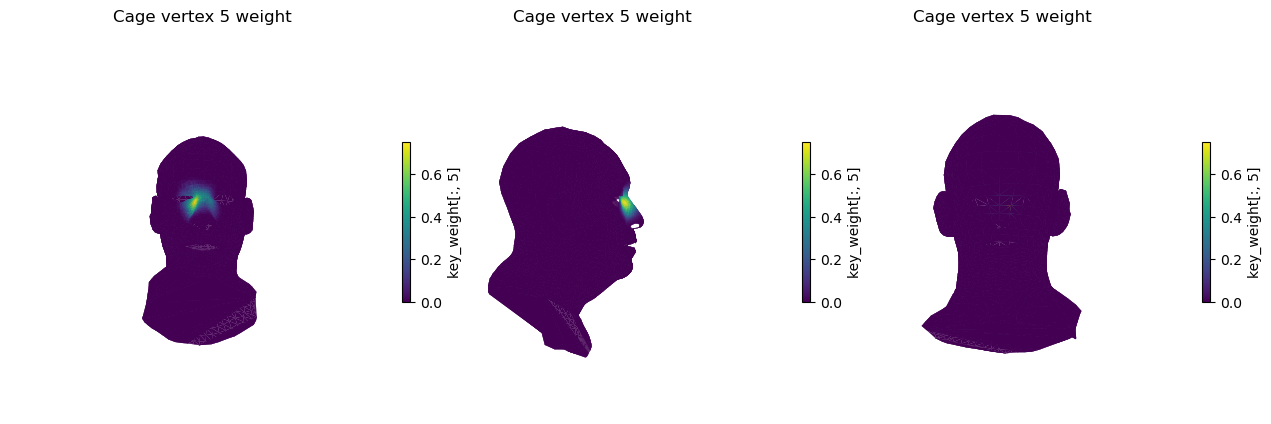

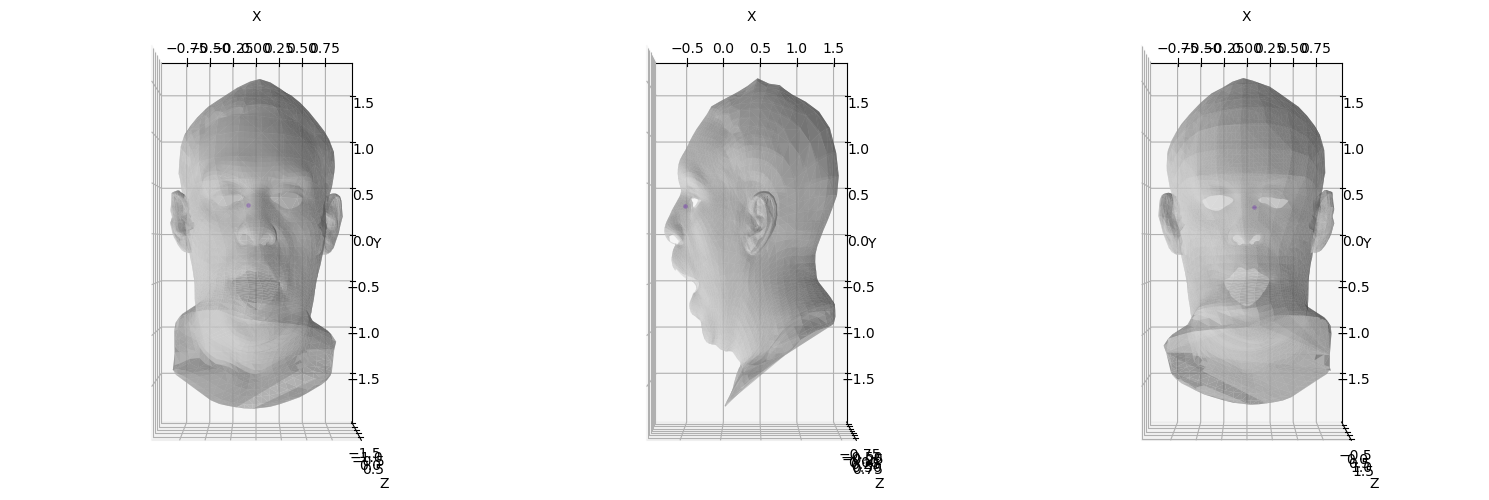

In [21]:
# recon_deformed[NNN], key_d[NNN], faces
NNN=0
print(key_weight[NNN].shape)
print(key_d.shape)
# for NC in range(10,15):
# for NC in range(55,100):
# for NC in [9,45,32,85,131]:
# for NC in range(96):
SELECT=5
for NC in [SELECT]:
    print(key_d.squeeze()[NC])
    
    vis_mesh_key_weight(
        pred_source[NNN].detach().cpu().numpy()*.6, tgt_mesh.faces, key_weight[NNN].detach().cpu().numpy(), 
        cage_idx=NC, 
        SIZE=4, yrot=0, cmap='viridis', show_cbar=True, 
        view_yrots=(0,90,180)
    )
    draw_mesh_and_key_v(pred_outputs[NNN], key_d[NNN][NC][None], key_weight[NNN],tgt_mesh.faces)
    # vis_mesh_key_weight(pred_deformed[NNN].detach().cpu().numpy(), mf_faces, key_weight[NNN].detach().cpu().numpy(), cage_idx=NC, SIZE=2, yrot=0, cmap='viridis')
    # vis_mesh_key_weight(recon_deformed[NNN].detach().cpu().numpy(), faces, key_weight[NNN].detach().cpu().numpy(), cage_idx=NC, SIZE=2, yrot=0, cmap='viridis')

In [88]:
def distance_energy(mesh_vertices, cage_vertices, tau=0.02, use_log=False):
    """
    Args:
        mesh_vertices: (B, N, 3)
        cage_vertices: (B, C, 3)
    Returns:
        loss
    """
    _tau = 1/tau
    _,C,_=cage_vertices.shape
    
    mesh_vertices_expand = mesh_vertices[:,:,None].repeat(1,1,C,1)
    cage_vertices_expand = cage_vertices[:,None]
    
    mesh_vertices_dir = mesh_vertices_expand - cage_vertices_expand
    # mesh_vertices_dist = torch.linalg.norm(mesh_vertices_dir, dim=-1)
    
    # flip
    mesh_vertices_dist = mesh_vertices_dist / mesh_vertices_dist.max(1).values.unsqueeze(-2)
    
    mesh_vertices_dist = 1 - mesh_vertices_dist
    
    # if use_log:
    #     dist_energy = torch.nn.functional.softmax(mesh_vertices_dist * _tau, dim=1)
    # else:
    #     dist_energy = torch.nn.functional.log_softmax(mesh_vertices_dist * _tau, dim=1)
        
    return dist_energy

def distance_regularization_loss(mesh_vertices, cage_vertices, coordinate_weight, tau=0.02, return_e=False):
    """
    Args:
        mesh_vertices: (B, N, 3)
        cage_vertices: (B, C, 3)
        coordinate_weight: (B, N, C)
    Returns:
        loss
    """
    #dist_energy = distance_energy(mesh_vertices, cage_vertices, tau=tau)
    dist_energy = distance_energy(mesh_vertices, cage_vertices, tau=tau, use_log=False)
    
#     loss = torch.nn.functional.cross_entropy(dist_energy, coordinate_weight.detach()) # less effective
#     loss = torch.nn.functional.cross_entropy(dist_energy, coordinate_weight) # less effective
    loss = torch.nn.functional.kl_div(dist_energy, torch.nn.functional.softmax(coordinate_weight, dim=-2))
#     loss = torch.nn.functional.kl_div(dist_energy, coordinate_weight)
    
    if return_e:
        return loss, dist_energy
    return loss


def distance_loss(mesh_vertices, cage_vertices, coordinate_weight, tau=0.02, return_e=False):
    """
    Args:
        mesh_vertices: (B, N, 3)
        cage_vertices: (B, C, 3)
        coordinate_weight: (B, N, C)
    Returns:
        loss
    """
    _,C,_=cage_vertices.shape
    
    mesh_vertices_expand = mesh_vertices[:,:,None].repeat(1,1,C,1)
    cage_vertices_expand = cage_vertices[:,None]
    
    mesh_vertices_dist = (mesh_vertices_expand - cage_vertices_expand)**2
    # mesh_vertices_dist = torch.linalg.norm(mesh_vertices_dist, dim=-1)
#     print(mesh_vertices_expand.shape)
#     print(cage_vertices_expand.shape)
#     print(mesh_vertices_dist.shape)
#     print(coordinate_weight.shape)
    # return (mesh_vertices_dist * coordinate_weight.unsqueeze(-1) ).mean()
    w = torch.softmax((coordinate_weight / tau), dim=-1)
    return (mesh_vertices_dist * w.unsqueeze(-1) ).mean()

torch.Size([1, 5223, 128])
torch.Size([1, 128, 3])
torch.Size([1, 5223, 128, 3])
torch.Size([1, 1, 128, 3])
3 tensor([[2313, 2301, 1962, 4922, 4910, 4922, 4912, 4915, 4922, 4618, 2300, 1919,
         4922, 2300, 2302, 2301, 4922, 4921, 4922, 4921, 2308, 4920, 2053, 4646,
         4923, 4915, 2308, 1790, 4915, 4913, 4922, 1986, 2296, 4915, 4922, 2297,
         2301, 4570, 2301, 2300, 4920, 2297, 2301, 4449, 2296, 2043, 4922, 4915,
         2313, 4913, 1790, 4922, 2039, 4923, 4921, 2302, 4455, 4923, 4915, 2301,
         4922, 4923, 2302, 2042, 4914, 4922, 4915, 4923, 4922, 2301, 1918, 4596,
         2301, 4455, 2039, 4910, 4922, 2302, 4449, 2223, 2301, 4449, 2313, 1919,
         1790, 2301, 4570, 4922, 4912, 4457, 4915, 2301, 4449, 4913, 4923, 4923,
         2300, 2301, 4922, 4922, 4455, 4923, 4912, 4637, 4922, 2301, 2313, 2301,
         4449, 2296, 4922, 4922, 2300, 4914, 4915, 2037, 1962, 2302, 4915, 4922,
         4915, 4914, 4923, 4920, 4922, 2313, 1962, 4552]], device='cuda:0')
3 to

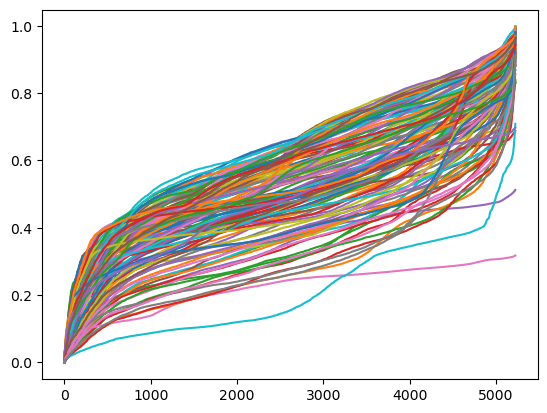

In [31]:
from torch_geometric.utils import geodesic_distance

# def distance_energy(mesh_vertices, cage_vertices, tau=0.02, use_log=False):
#     """
#     Args:
#         mesh_vertices: (B, N, 3)
#         cage_vertices: (B, C, 3)
#     Returns:
#         loss
#     """
print(key_weight.shape)
print(key_d.shape)
cage_vertices = key_d[:,:128]#.detach()[:, 0, None].requires_grad_(True)
_coord_weight = key_weight[:, :, 0, None]

mesh_vertices = pred_source
B, V, _ = mesh_vertices.shape

_tau = 1/0.02
_,C,_=cage_vertices.shape

mesh_vertices_expand = mesh_vertices[:,:,None].repeat(1,1,C,1)
cage_vertices_expand = cage_vertices[:,None]

print(mesh_vertices_expand.shape)
print(cage_vertices_expand.shape)
#mesh_vertices_dir = mesh_vertices_expand - cage_vertices_expand
# mesh_vertices_dist = torch.sqrt(torch.square(mesh_vertices_expand - cage_vertices_expand))
mesh_vertices_dist = torch.linalg.norm(mesh_vertices_expand - cage_vertices_expand, dim=-1)
# mesh_vertices_dist = torch.linalg.norm(torch.square(mesh_vertices_expand - cage_vertices_expand), dim=-1)
# mesh_vertices_dist = torch.square(torch.linalg.norm(mesh_vertices_expand - cage_vertices_expand, dim=-1))

# print('2',mesh_vertices_dist.shape)
# mesh_vertices_dist = torch.square(mesh_vertices_dist)
# mesh_vertices_dist = torch.sqrt(torch.square(mesh_vertices_dist))

# print('3',mesh_vertices_dist.shape)
# mesh_vertices_dist = torch.abs(mesh_vertices_expand - cage_vertices_expand)
# mesh_vertices_dist = torch.linalg.norm(mesh_vertices_dir, dim=-1)


candidate_idx = torch.argmax(mesh_vertices_dist, dim=1)#.squeeze()
print('3',candidate_idx)
print('3',candidate_idx.shape)


mesh_vertices_max = mesh_vertices_dist.max(-2).values.unsqueeze(1)
print('4',mesh_vertices_max.shape)
# flip
mesh_vertices_dist = 1 - (mesh_vertices_dist / mesh_vertices_max)
print(mesh_vertices_dist.max(), mesh_vertices_dist.min())
print('5',mesh_vertices_dist.shape)
# candidate_vert = mesh_vertices[torch.arange(B), candidate_idx[torch.arange(B)]]
# print('5',mesh_vertices.shape, candidate_vert.shape)


with torch.no_grad():
    max_gdistance = 1.0
    pos = torch.from_numpy(tgt_mesh.vertices).to(device)
    face = torch.from_numpy(tgt_mesh.faces.transpose(1,0)).to(device)
    GD = torch.zeros((B, C, V)).to(device)
    
    for i, c_idx in enumerate(candidate_idx):
        GD[i] = geodesic_distance(
            pos, face, 
            c_idx, # indicies not positions
            norm=False,
            max_distance=max_gdistance,
        )
    GD = GD.transpose(2,1)

    if 0:
        GD[GD>=max_gdistance]=max_gdistance
        GD = 1 - (GD / max_gdistance)
    else:
        GD = GD >= max_gdistance
        GD = ~GD * 1.0
print('6', GD.shape)

# mesh_vertices_dist = 1 - mesh_vertices_dist
    
    # if use_log:
    #     dist_energy = torch.nn.functional.softmax(mesh_vertices_dist * _tau, dim=1)
    # else:
    #     dist_energy = torch.nn.functional.log_softmax(mesh_vertices_dist * _tau, dim=1)
        
    # return dist_energy

# qwe=key_weight[:, :, 0, None].clone()
# asd = np.sort(qwe[0,:,0].detach().cpu().numpy())
asd = (mesh_vertices_dist).detach().cpu().numpy().squeeze()
# asd = (mesh_vertices_dist * GD).detach().cpu().numpy().squeeze()
# asd = (GD).detach().cpu().numpy().squeeze()

# asd = np.sort(asd[...,0])
print(asd.shape, asd.min(), asd.max())
# asd = np.sort(asd[:,0], 0)
asd = np.sort(asd, 0)
# asd = asd[1:] - asd[:-1]
# plt.plot(asd[:,10])
plt.plot(asd)
# plt.yscale('log')
# plt.xscale('log')
plt.show()

torch.Size([1, 5223, 128])
torch.Size([1, 5223, 128])
tensor(0., device='cuda:0') tensor(0.8983, device='cuda:0')


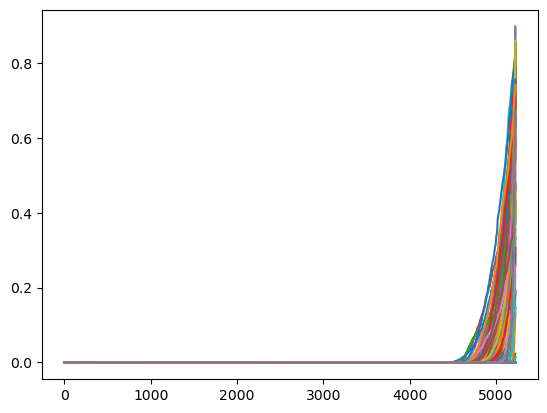

In [28]:
_coord_weight = key_weight#[:, :, 0, None]
print(key_weight.shape)
print(_coord_weight.shape)
print(key_weight.min(), key_weight.max())

zxc = np.sort(_coord_weight.detach().cpu().numpy()[0], 0)
# asd = asd[1:] - asd[:-1]
# plt.plot(asd[:,10])
plt.plot(zxc)
# plt.yscale('log')
# plt.xscale('log')
plt.show()

In [ ]:
def distance_loss2(mesh_vertices, cage_vertices, coordinate_weight, tau=0.02, return_e=False):
    B, V, _ = mesh_vertices.shape
    
    _tau = 1/0.02
    _,C,_=cage_vertices.shape
    
    mesh_vertices_expand = mesh_vertices[:,:,None].repeat(1,1,C,1)
    cage_vertices_expand = cage_vertices[:,None]
    
    mesh_vertices_dist = torch.linalg.norm(mesh_vertices_expand - cage_vertices_expand, dim=-1)
    
    candidate_idx = torch.argmax(mesh_vertices_dist, dim=1)
    
    
    mesh_vertices_max = mesh_vertices_dist.max(-2).values.unsqueeze(1)
    
    mesh_vertices_dist = 1 - (mesh_vertices_dist / mesh_vertices_max)
    
    return F.mse_loss(mesh_vertices_dist, coordinate_weight) 

In [11]:
c_vert.shape

torch.Size([128, 3])

In [414]:
# _cage_vertex = key_d.detach()[...,:1,:].requires_grad_(True)
# _coord_weight = key_weight[:, :, 0, None]
# _mesh_vertex = pred_source
# print(_mesh_vertex.shape, _coord_weight.shape,_cage_vertex.shape)

# qwe = distance_energy(_mesh_vertex, _cage_vertex, tau=1)
# print(qwe.shape, qwe.min(), qwe.max())
# qwe = np.sort(qwe.detach().cpu().numpy().squeeze().squeeze())
# print(qwe.shape, qwe.min(), qwe.max())

# # qwe = np.sort(qwe)
# plt.plot(qwe)
# plt.show()

# qwe = np.sort(_coord_weight.detach().cpu().numpy().squeeze().squeeze())
# plt.plot(qwe)
# plt.show()

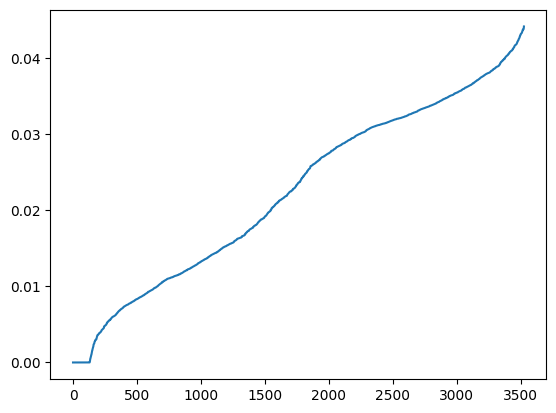

In [163]:
# _cage_vertex = key_d[:, 0][None].clone().requires_grad_(True)
# _coord_weight = key_weight[:, :, 0, None].clone().requires_grad_(True)
# _mesh_vertex = pred_outputs.clone().requires_grad_(True)

# qwe=torch.nn.functional.softmax(_coord_weight, dim=-2)#.shape
qwe=key_weight[:, :, 0, None].clone()
asd = np.sort(qwe[0,:,0].detach().cpu().numpy())
# asd = asd[1:] - asd[:-1]
plt.plot(asd)
plt.show()

In [112]:
loss = distance_loss(_mesh_vertex, _cage_vertex, _coord_weight, tau=0.05, return_e=True)

In [89]:
# _cage_vertex = key_d[:, 0][None].clone().requires_grad_(True)
# _coord_weight = key_weight[:, :, 0, None].clone().requires_grad_(True)
_cage_vertex = key_d[:, [0,1]].clone().requires_grad_(True)
_coord_weight = key_weight[:, :, [0,1]].clone().requires_grad_(True)
_mesh_vertex = pred_outputs.clone().requires_grad_(True)

print(_mesh_vertex.shape, _coord_weight.shape,_cage_vertex.shape)
optimizer = torch.optim.Adam([_cage_vertex, _coord_weight], lr=2e-4)
# optimizer = torch.optim.Adam([_cage_vertex], lr=2e-4)

pbar = tqdm(range(1_000))
for i in pbar:
    optimizer.zero_grad()
#     loss = distance_regularization_loss(_mesh_vertex, _cage_vertex, _coord_weight, tau=0.02)
#     loss, dist_energy = distance_regularization_loss(_mesh_vertex, _cage_vertex, _coord_weight, tau=1, return_e=True)
#     loss, dist_energy = distance_regularization_loss(
#         _mesh_vertex, _cage_vertex, _coord_weight.detach(), tau=1, return_e=True
#     )
#     loss = distance_loss(_mesh_vertex, _cage_vertex, _coord_weight.detach(), return_e=True)
    loss = distance_loss(_mesh_vertex, _cage_vertex, _coord_weight, return_e=True)
#     loss = -loss
    loss.backward()
    pbar.set_description(f'{loss.item()}')
    
    if i % 500 ==0:
        # print(dist_energy.min(), dist_energy.max())
        print(_coord_weight.min(), _coord_weight.max())
    optimizer.step()

torch.Size([1, 5223, 3]) torch.Size([1, 5223, 2]) torch.Size([1, 2, 3])


0.23819346725940704:   4%|▍         | 42/1000 [00:00<00:02, 414.03it/s]

tensor(0., device='cuda:0', grad_fn=<MinBackward1>) tensor(0.7914, device='cuda:0', grad_fn=<MaxBackward1>)


0.1713734120130539:  59%|█████▉    | 588/1000 [00:01<00:00, 448.61it/s] 

tensor(-0.0615, device='cuda:0', grad_fn=<MinBackward1>) tensor(0.7914, device='cuda:0', grad_fn=<MaxBackward1>)


0.15321913361549377: 100%|██████████| 1000/1000 [00:02<00:00, 447.23it/s]


In [90]:
_cage_vertex.shape

torch.Size([1, 2, 3])

verts min/max: [-0.6445207 -1.3186594 -0.8970453] [0.60785353 0.9020057  0.4740508 ]


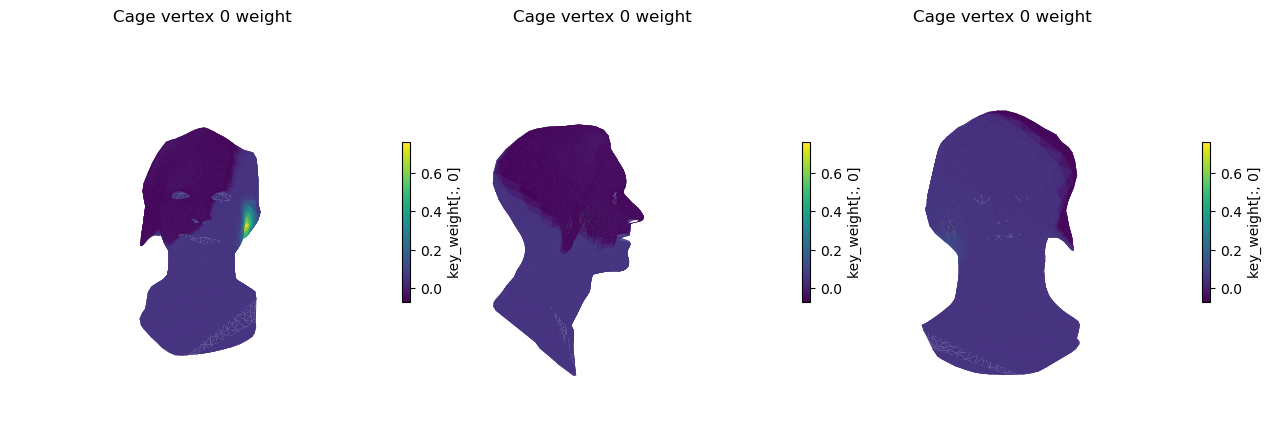

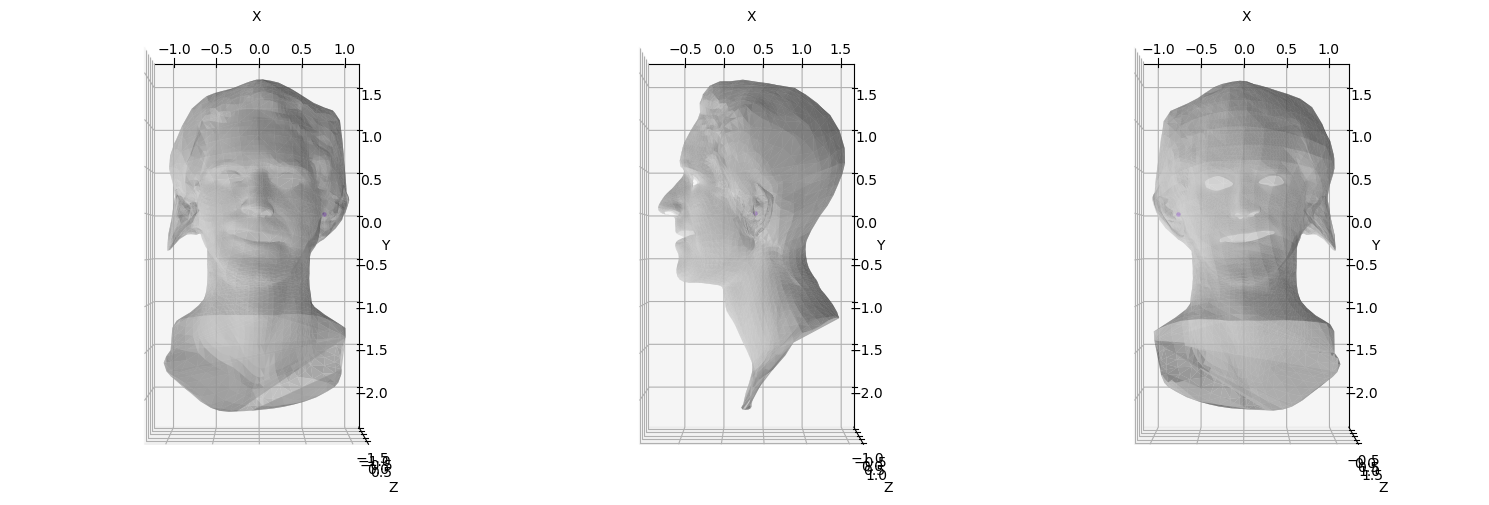

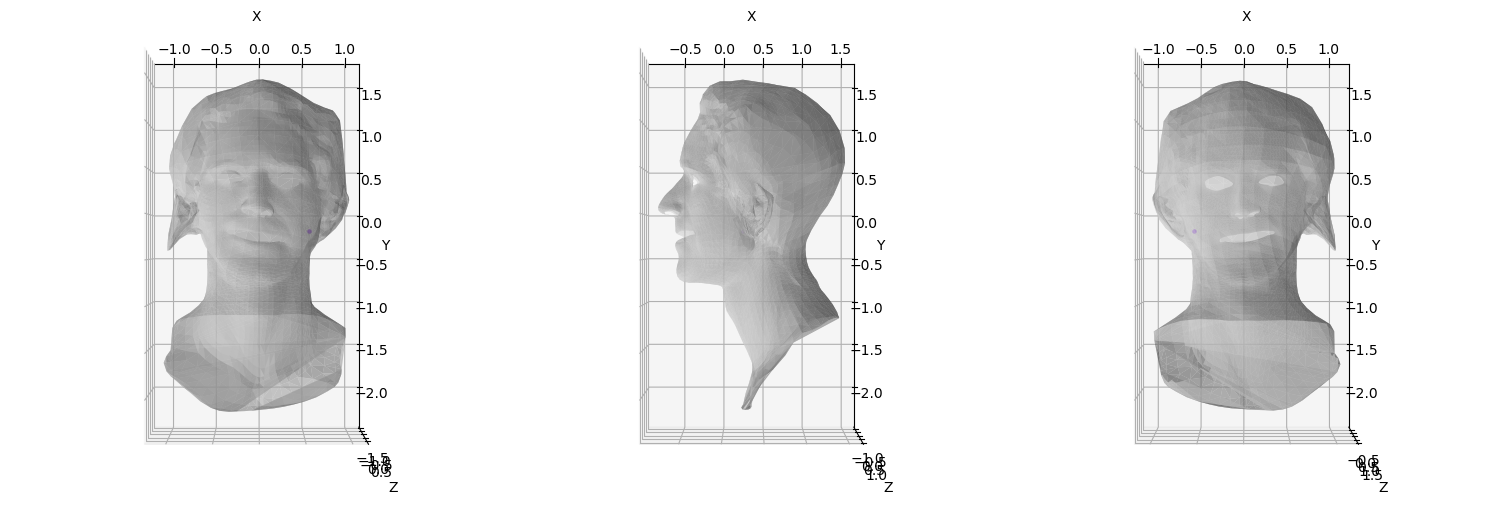

In [91]:
vis_mesh_key_weight(
    pred_outputs[0].detach().cpu().numpy()*.6, tgt_mesh.faces, _coord_weight[0].detach().cpu().numpy(), 
    cage_idx=0,
    SIZE=4, yrot=0, cmap='viridis', show_cbar=True, 
    view_yrots=(0,90,180)
)
draw_mesh_and_key_v(pred_outputs[0], key_d[:, 0], _coord_weight[0], tgt_mesh.faces)
draw_mesh_and_key_v(pred_outputs[0], _cage_vertex[:,0], _coord_weight[0], tgt_mesh.faces)


torch.Size([1, 3525, 3]) torch.Size([1, 3525, 1]) torch.Size([1, 1, 3])
torch.Size([1, 3525, 1]) tensor(0.0002, device='cuda:0', grad_fn=<MinBackward1>) tensor(0.0005, device='cuda:0', grad_fn=<MaxBackward1>)
(3525,) 0.00017812743 0.00047425894


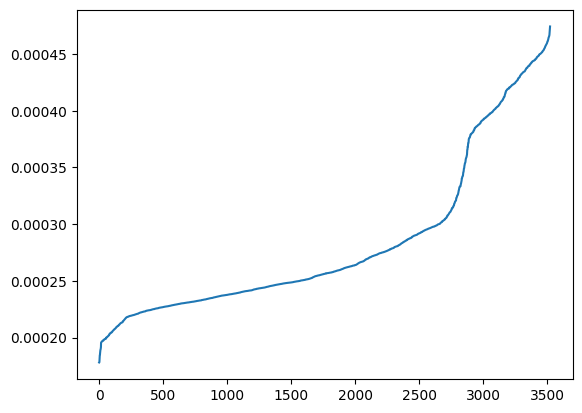

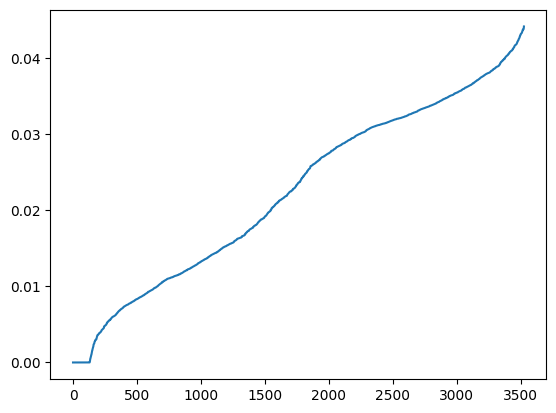

In [354]:
# _cage_vertex = key_d.detach()[...,:1,:].requires_grad_(True)
# _coord_weight = key_weight[:, :, 0, None]
# _mesh_vertex = pred_source
print(_mesh_vertex.shape, _coord_weight.shape,_cage_vertex.shape)

qwe = distance_energy(_mesh_vertex, _cage_vertex, tau=1)
print(qwe.shape, qwe.min(), qwe.max())
qwe = np.sort(qwe.detach().cpu().numpy().squeeze().squeeze())
print(qwe.shape, qwe.min(), qwe.max())

# qwe = np.sort(qwe)
plt.plot(qwe)
plt.show()

qwe = np.sort(_coord_weight.detach().cpu().numpy().squeeze().squeeze())
plt.plot(qwe)
plt.show()

# Retarget animation

In [3]:
from dataloader_CBD import (
    EvalDataset,
    CBDDataBatch_eval,
    CBD_collate_wrapper_eval,
)
from functools import partial
from tqdm import tqdm
from glob import glob
import igl

import ipywidgets as widgets
import matplotlib.pyplot as plt

try:
    from matplotrender import *
except:
    !pip install git+https://github.com/chacorp/matplotrender.git
    from matplotrender import *

In [4]:
def get_mesh(selection, dataset, SELECT_MESH):
    if selection=='ict'or selection=='ict-cap':
        # id_vecs = np.load(f'{__abs_path__}/data/ICT_live_100/iden_vecs.npy')
        # id_vecs = np.load(f'{__abs_path__}/ict_face_pt/random_identity_vecs.npy')[:101]
        id_vecs = torch.load(f'{__abs_path__}/ict_face_pt/ict_id_vecs_test.pt').numpy()
        id_disps = dataset.ict_face_model.get_id_disp(id_vecs[SELECT_MESH])
        mesh_v = dataset.ict_face_model.neutral_verts.squeeze() + id_disps.squeeze()
        
        return mesh_v, dataset.ict_face_model.faces
    else:
        if selection=='voca':
            mesh = dataset.voca_mesh
        elif selection=='biwi':
            # mesh = dataset.biwi_mesh            
            biwi_trimesh = trimesh.load(f'{__abs_path__}/test-mesh/BIWI.ply')
            with open(f'{__abs_path__}/test-mesh/biwi_templates.pkl', 'rb') as f:
                mesh = pickle.load(f)
                
            mesh['face']=biwi_trimesh.faces
        elif selection=='mf_SEN':
            mesh = dataset.mf_SEN_mesh
        elif selection=='coma':
            mesh = dataset.coma_mesh
        elif selection=='mf_ROM':
            mesh = dataset.mf_ROM_mesh

        mesh_list = [idname for idname in mesh.keys() if idname!='face']
        mesh_v = mesh[mesh_list[SELECT_MESH]]

        if selection=='biwi':
            m_align = np.load(f'{__abs_path__}/utils/biwi/align.npy')
            mesh_v = np.concatenate((mesh_v,np.ones((mesh_v.shape[0],1))), axis=1) @ m_align.T
        return mesh_v, mesh['face']

In [5]:
device='cuda:0'
SRC_SELECT_DATA=4
SRC_SELECT_MESH=12
EXP_NUM=0

BS=1
data_name_list = ['voca','biwi','mf_SEN','coma','mf_ROM','ict','ict-cap'] # 0 1 2 3 4 5 6
src_selection = data_name_list[SRC_SELECT_DATA]

src_dataset = EvalDataset(
    data_name=src_selection, 
    toggle=False, 
    ict_cap_id_num  = SRC_SELECT_MESH,
    ict_cap_exp_num = EXP_NUM,
) # if eve-s01

src_dataloader = torch.utils.data.DataLoader(
    src_dataset,
    batch_size=BS,
    collate_fn=partial(CBD_collate_wrapper_eval, device=device),
)
len_data = len(src_dataset)
len_dataloader = len(src_dataloader)
print(f'max data length: {len_data}')
print(f'max dataloader: {len_dataloader}')

src_v, src_f = get_mesh(src_selection, src_dataset, SRC_SELECT_MESH)
src_n = igl.per_vertex_normals(src_v, src_f)

mf ROM data list exists: /source/sihun/NeuralFacialAnimation/utils/data/mf_ROM_vertex_data_test.txt
max data length: 11649
max dataloader: 11649


In [6]:
TGT_SELECT_DATA=5
TGT_SELECT_mesh=0

# ict test id [2 4 5 6 10 11 12] (at NFS)
# ict test id [0 5 6]
data_name_list = ['voca','biwi','mf_SEN','coma','mf_ROM','ict','ict-cap']
tgt_selection = data_name_list[TGT_SELECT_DATA]

tgt_dataset = EvalDataset(data_name=tgt_selection, toggle=False, ict_cap_id_num=TGT_SELECT_mesh) # if eve-s01

tgt_v, tgt_f = get_mesh(tgt_selection, tgt_dataset, TGT_SELECT_mesh)

tgt_n = igl.per_vertex_normals(tgt_v, tgt_f)
tgt_v_th = torch.tensor(tgt_v).float()[None].to(device)
tgt_n_th = torch.tensor(tgt_n).float()[None].to(device)

(5223, 3) (10278, 3) (11248, 3) (22288, 3)


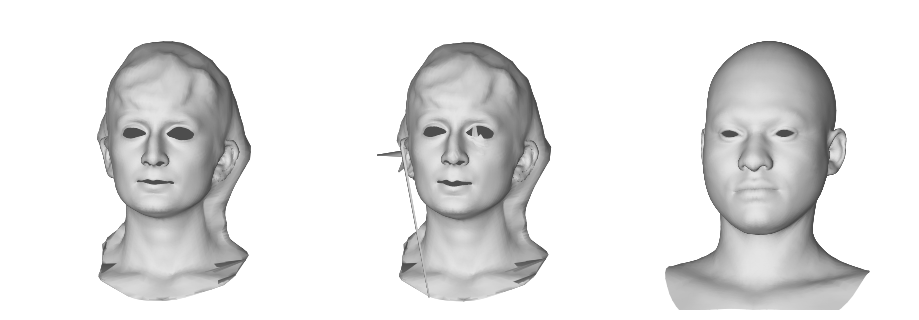

In [8]:
M_SCALE = 0.5
print(src_v.shape, src_f.shape, tgt_v.shape, tgt_f.shape)
v_list=[ src_v, tgt_v ]
f_list=[ src_f, tgt_f ]
SIZE=3
rot_list=[[0,-10,0]]

plot_mesh_gouraud(v_list, f_list, mesh_scale=M_SCALE,
        rot_list=rot_list*len(v_list), size=SIZE, mode='shade', bg_black=False)

In [62]:
# file_name = 'coma-to-mf_ROM'
# file_name = 'mf_ROM_test-to-mf_ROM_val'
# file_name = 'mf_ROM_test-to-mf_ROM_test'
# file_name = 'mf_SEN_test-to-mf_SEN_test'
if src_selection == 'ict-cap':
    file_name = f'{src_selection}-ID_{SRC_SELECT_MESH:03d}_test-to-{tgt_selection}-ID_{TGT_SELECT_mesh:03d}_test_{EXP_NUM:02d}'
else:
    if 'ict' in  tgt_selection:
        file_name = f'{src_selection}_test-to-{tgt_selection}_test-ID_{TGT_SELECT_mesh:03d}'
    else:
        file_name = f'{src_selection}_test-to-{tgt_selection}_test'
        # file_name = f'{src_selection}_test-to-{tgt_selection}_test'
        # file_name = f'{src_selection}_test-to-{tgt_selection}_val'
        # file_name = f'{src_selection}_test-to-{tgt_selection}_train'
a2b_retarget_path = __abs_path__ + '/eval_CBD/'+opts.ckpt.split('/')[-1]+'/'+file_name
print(a2b_retarget_path)
os.makedirs(a2b_retarget_path, exist_ok=True) 

/source/sihun/NeuralFacialAnimation/eval_CBD/2025-10-09-02-04-49-NGBCv5/mf_ROM_test-to-ict_test-ID_000


  0%|                                                                      | 0/3260 [00:00<?, ?it/s]


     source neutral 	|	 source expression 	|	 target neutral 	|	 target expression


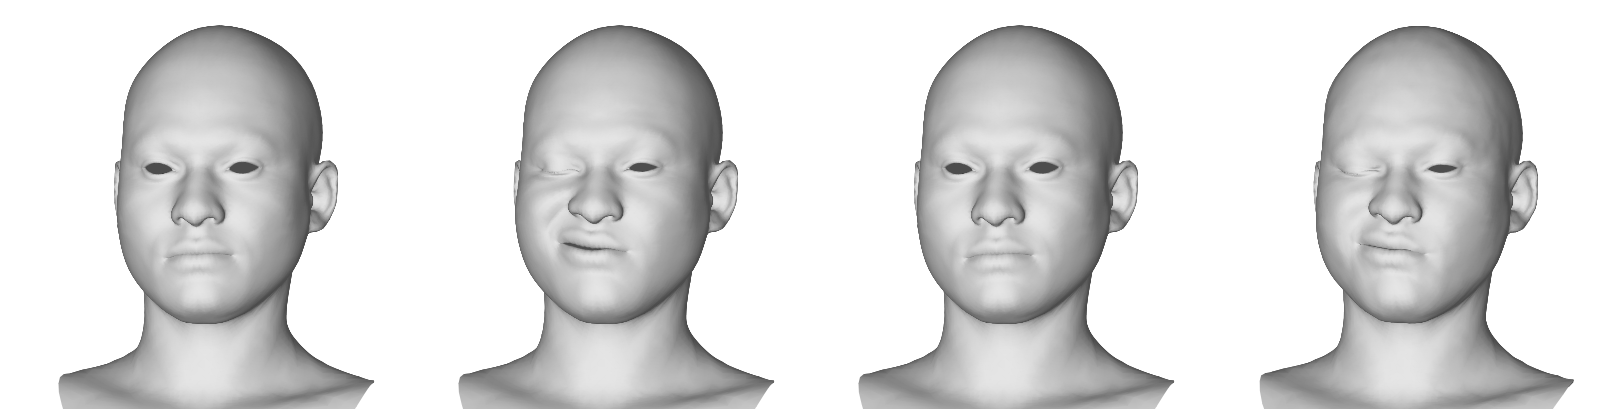

In [39]:
FRAME=0
pbar = tqdm(enumerate(src_dataloader), total=len_dataloader, ncols=100)
for index, batch in pbar:
    if FRAME == index:
        with torch.no_grad():
            pred_outputs, pred_source, exp_z_d, key_d, exp_z_s, key_s, key_weight = trainer.model.retarget(
                batch.template, batch.template_normal, batch.vertices, batch.vertices_normal, tgt_v_th, tgt_n_th,
                mesh_data=batch.mesh_data, out_kw=True
            )

        pred_outputs_np = pred_outputs.detach().cpu().numpy()
        for b_idx in range(BS):
            np.save(a2b_retarget_path+f'/{index*BS+b_idx:05d}', pred_outputs_np[b_idx])
        break
    else:
        continue

SIZE=6
M_SCALE=.58
SAVE=0
M_SCALE_Zoom=2

M_trns=np.array([0,0.,0])
v_list=[
    batch.template.detach().cpu().numpy()[0],
    batch.vertices.detach().cpu().numpy()[0],
    tgt_v,
    pred_outputs.detach().cpu().numpy()[0],
]
# v_list = [v * M_SCALE + M_trns for v in v_list]
f_list=[ src_f, src_f, tgt_f, tgt_f]

print('     source neutral \t|\t source expression \t|\t target neutral \t|\t target expression')
plot_mesh_gouraud(v_list, f_list, mesh_scale=M_SCALE, mesh_trans=M_trns,
        rot_list=rot_list*len(v_list), size=4, mode='shade', bg_black=False)
# plot_mesh_gouraud(v_list, f_list, mesh_scale=M_SCALE_Zoom, mesh_trans=M_trns,
#         rot_list=rot_list*len(v_list), size=4, mode='shade', bg_black=False)

In [149]:
SRC_SELECT_MESH==TGT_SELECT_mesh

True

In [63]:
print(a2b_retarget_path)

/source/sihun/NeuralFacialAnimation/eval_CBD/2025-10-09-02-04-49-NGBCv5/mf_ROM_test-to-ict_test-ID_000


In [24]:
print(a2b_retarget_path)

SELF_RETARGET = SRC_SELECT_MESH==TGT_SELECT_mesh
if SELF_RETARGET:
    print('self-retargeting!')
    pbar = tqdm(enumerate(src_dataloader), total=len_dataloader, ncols=100)
    for index, batch in pbar:
        # predict_coordinate(tgt_neu_vert, tgt_neu_norm)
        # retarget_animation(src_neu_vert, src_neu_norm, src_def_vert, src_def_norm, key_weight)
        
        with torch.no_grad():
            pred_outputs, pred_source, exp_z_d, key_d, exp_z_s, key_s, key_weight = trainer.model.retarget(
                batch.template, batch.template_normal, batch.vertices, batch.vertices_normal, batch.template, batch.template_normal,
                mesh_data=batch.mesh_data, out_kw=True
            )
    
        pred_outputs_np = pred_outputs.detach().cpu().numpy()
        for b_idx in range(BS):
            if b_idx < pred_outputs_np.shape[0]:
                np.save(a2b_retarget_path+f'/{index*BS+b_idx:05d}', pred_outputs_np[b_idx])
else:
    print('cross-retargeting!')
    pbar = tqdm(enumerate(src_dataloader), total=len_dataloader, ncols=100)
    for index, batch in pbar:
        with torch.no_grad():
            pred_outputs, pred_source, exp_z_d, key_d, exp_z_s, key_s, key_weight = trainer.model.retarget(
                batch.template, batch.template_normal, batch.vertices, batch.vertices_normal, tgt_v_th, tgt_n_th,
                mesh_data=batch.mesh_data, out_kw=True
            )
    
        pred_outputs_np = pred_outputs.detach().cpu().numpy()
        for b_idx in range(BS):
            if b_idx < pred_outputs_np.shape[0]:
                np.save(a2b_retarget_path+f'/{index*BS+b_idx:05d}', pred_outputs_np[b_idx])

# NFR
### ICT self-retargeting    204/204 [33:25<17:56,  9.70s/it] 3260/3260 [39:46<00:00,  1.37it/s]
### MF_rom self-retargeting 729/729 [05:24<00:00,  2.25it/s]
                
# NFS
### ICT self-retargeting    204/204 [19:43<00:00,  5.80s/it] 3260/3260 [30:37<00:00,  1.77it/s] 
### MF_rom self-retargeting 729/729 [02:56<00:00,  4.13it/s]

# NBC (Ours)
### ICT self-retargeting    204/204 [11:28<00:00,  3.38s/it] 3260/3260 [23:46<00:00,  2.29it/s]
### MF_rom self-retargeting 729/729 [01:40<00:00,  7.29it/s] (frame: 11,664)

/source/sihun/NeuralFacialAnimation/eval_CBD/2025-10-09-02-04-49-NGBCv5/ict-cap-ID_000_test-to-mf_ROM-ID_012_test_01
cross-retargeting!


100%|███████████████████████████████████████████████████████████| 1147/1147 [14:08<00:00,  1.35it/s]


In [64]:
print(a2b_retarget_path)

SELF_RETARGET = SRC_SELECT_MESH==TGT_SELECT_mesh
if SELF_RETARGET:
    print('self-retargeting!')
    pbar = tqdm(enumerate(src_dataloader), total=len_dataloader, ncols=100)
    for index, batch in pbar:
        # predict_coordinate(tgt_neu_vert, tgt_neu_norm)
        # retarget_animation(src_neu_vert, src_neu_norm, src_def_vert, src_def_norm, key_weight)
        if index==0:
            src_template = batch.template
            src_template_normal = batch.template_normal
            with torch.no_grad():
                key_weight = trainer.model.predict_coordinate(src_template, src_template_normal)
        else:
            if (batch.template[0] - src_template[0]).mean() != 0:
                src_template = batch.template
                src_template_normal = batch.template_normal
                with torch.no_grad():
                    key_weight = trainer.model.predict_coordinate(src_template, src_template_normal)
                
        with torch.no_grad():
            pred_outputs, key_d = trainer.model.retarget_animation(
                batch.template, batch.template_normal, batch.vertices, batch.vertices_normal, key_weight
            )
            
        pred_outputs_np = pred_outputs.detach().cpu().numpy()
        for b_idx in range(BS):
            if b_idx < pred_outputs_np.shape[0]:
                np.save(a2b_retarget_path+f'/{index*BS+b_idx:05d}', pred_outputs_np[b_idx])
else:
    print('cross-retargeting!')
    key_weight = trainer.model.predict_coordinate(tgt_v_th, tgt_n_th)
    
    pbar = tqdm(enumerate(src_dataloader), total=len_dataloader, ncols=100)
    for index, batch in pbar:
        with torch.no_grad():            
            pred_outputs, key_d = trainer.model.retarget_animation(
                batch.template, batch.template_normal, batch.vertices, batch.vertices_normal, key_weight
            )
    
        pred_outputs_np = pred_outputs.detach().cpu().numpy()
        for b_idx in range(BS):
            if b_idx < pred_outputs_np.shape[0]:
                np.save(a2b_retarget_path+f'/{index*BS+b_idx:05d}', pred_outputs_np[b_idx])

/source/sihun/NeuralFacialAnimation/eval_CBD/2025-10-09-02-04-49-NGBCv5/mf_ROM_test-to-ict_test-ID_000
cross-retargeting!


100%|█████████████████████████████████████████████████████████| 11649/11649 [04:28<00:00, 43.33it/s]


## vis weight

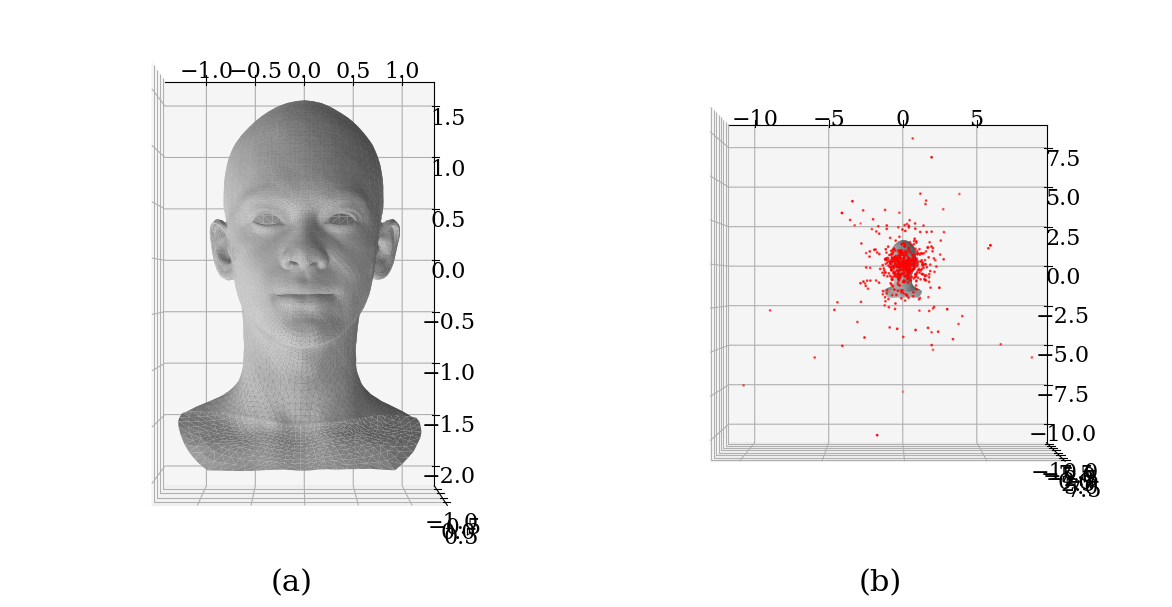

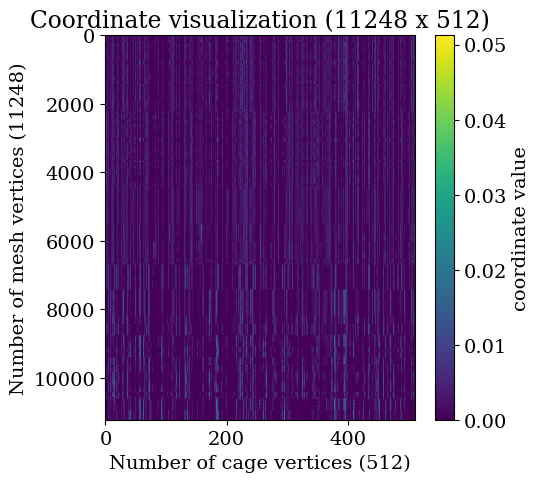

In [79]:
def draw_mesh_and_key_v(template_v_th, key_v, faces):
    
    rc = {
        "font.family" : "serif", 
        "font.size" : 16,
        "mathtext.fontset" : "stix",
    }
    FT = 22
    plt.rcParams.update(rc)
    plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]

    mesh_v = template_v_th.detach().cpu().numpy()
    points = key_v.detach().cpu().numpy()

    alpha=1.0
    
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(121, projection='3d')
    # ax.plot_surface(mesh_v[:, 0], mesh_v[:, 1], mesh_v[:, 2])
    ax.plot_trisurf(mesh_v[:, 0], mesh_v[:, 1], mesh_v[:, 2],
                    # triangles=faces, alpha=alpha, linewidth=0.0)
                    triangles=faces, alpha=alpha, color='lightgray', linewidth=0.0)
                    # triangles=faces, alpha=alpha, color='lightblue', linewidth=0.0)
                    # triangles=faces, alpha=alpha, color='gray', linewidth=0.0)
    ax.view_init(elev=90, azim=-90)
    # ax.set_aspect('equal')
    ax.set_box_aspect([1,1.5,1])
    ax.set_title("(a)", fontsize=FT, y=-0.05)
    
    ax = fig.add_subplot(122, projection='3d')    
    ax.plot_trisurf(mesh_v[:, 0], mesh_v[:, 1], mesh_v[:, 2],
                    # triangles=faces, alpha=alpha, linewidth=0.0)
                    triangles=faces, alpha=alpha, color='lightgray', linewidth=0.0)
                    # triangles=faces, alpha=alpha, color='lightblue', linewidth=0.0)
                    # triangles=faces, alpha=alpha, color='gray', linewidth=0.0)

    ax.scatter(points[:, 0], points[:, 1], points[:, 2], color='r', s=1)    
    ax.view_init(elev=90, azim=-90)
    # ax.set_aspect('equal')
    ax.set_box_aspect([1.5, 1.5, 1.5])
    ax.set_title("(b)", fontsize=FT, y=-0.05)
    plt.tight_layout()
    plt.show()

def draw_key_weight(data):
    rc = {
        "font.family" : "serif", 
        "font.size" : 14,
        "mathtext.fontset" : "stix",
    }
    FT = 20
    plt.rcParams.update(rc)
    plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
    
    data = data.detach().cpu().numpy()
    num_sample, num_cage = data.shape[0], data.shape[1]
    #normed = (data - data.min(1,keepdims=True)) / (data.max(1,keepdims=True) - data.min(1,keepdims=True))
    #print(normed.min(),normed.max())
    
    plt.figure(figsize=(5, 5))  # set figure size to 5x5 inches
    plt.imshow(data, aspect='auto', cmap='viridis', vmin=data.min(), vmax=data.max())  # aspect='auto' to stretch
    plt.colorbar(label='coordinate value')  # optional colorbar
    
    plt.xlabel(f"Number of cage vertices ({num_cage})")
    plt.ylabel(f"Number of mesh vertices ({num_sample})")
    plt.title(f"Coordinate visualization ({num_sample} x {num_cage})")
    plt.show()
    
NNN=0 
# print(key_weight[0].sum(0).shape, key_weight[0].sum(0))
# print(key_weight[0,0])
# print(torch.allclose(key_weight[0], key_weight[1]))
# print(torch.nn.functional.mse_loss(key_weight[0], key_weight[1]).item())

# print(key_weight[0].sum(1).shape, key_weight[0].sum(1))
draw_mesh_and_key_v(pred_source[NNN], key_d[NNN], tgt_f)
draw_key_weight(key_weight[0])

## save GT

In [45]:
# file_name = 'GT-mf_ROM_test-to-mf_ROM_test'
# GT_file_name = 'GT-'+file_name
GT_file_name = f'GT-{src_selection}_test-to-{src_selection}_test_{EXP_NUM:02d}'

GT_a2b_retarget_path = __abs_path__ + '/eval_CBD/'+ GT_file_name
print(GT_a2b_retarget_path)
os.makedirs(GT_a2b_retarget_path, exist_ok=True) 

/source/sihun/NeuralFacialAnimation/eval_CBD/GT-ict-cap_test-to-ict-cap_test_00


In [213]:
pbar = tqdm(enumerate(src_dataloader), total=len_dataloader, ncols=100)
for index, batch in pbar:
    gt_outputs_np = batch.vertices.detach().cpu().numpy()
    for b_idx in range(BS):
        if b_idx < gt_outputs_np.shape[0]:
            np.save(GT_a2b_retarget_path+f'/{index*BS+b_idx:05d}', gt_outputs_np[b_idx])

100%|███████████████████████████████████████████████████████████| 1147/1147 [08:11<00:00,  2.33it/s]


## load

In [46]:
print(a2b_retarget_path)
mesh_file_paths = sorted(glob(a2b_retarget_path+'/*.npy'))
len_mesh_file_paths=len(mesh_file_paths)
print(len(mesh_file_paths))

print(GT_a2b_retarget_path)
GT_mesh_file_paths = sorted(glob(GT_a2b_retarget_path+'/*.npy'))
GT_len_mesh_file_paths=len(GT_mesh_file_paths)
print(len(GT_mesh_file_paths))

/source/sihun/NeuralFacialAnimation/eval_CBD/2025-10-09-02-04-49-NGBCv5/ict-cap-ID_002_test-to-mf_ROM-ID_012_test_00
183
/source/sihun/NeuralFacialAnimation/eval_CBD/GT-ict-cap_test-to-ict-cap_test_00
183


In [22]:
__mse__ = 0
for gt, pred in zip(GT_mesh_file_paths, mesh_file_paths):
    pred = np.load(pred)
    gt = np.load(gt)
    __mse__ += np.power(gt - pred, 2).mean()
__mse__ = __mse__ / len(GT_mesh_file_paths)
print(f"MSE: {__mse__:.5e}")

MSE: 3.70772e-04


In [60]:
src_f.shape

(22288, 3)

In [47]:
SAVE=0
rot_list=[[0,-10,0]]
M_SCALE=0.6
def update_frame(frame):
    plt.close()
    
    vvv= np.load(mesh_file_paths[frame]).squeeze()
    vvvGT= np.load(GT_mesh_file_paths[frame]).squeeze()
    
    v_list = [vvvGT, vvv]
    f_list = [src_f, tgt_f]
    # plot_mesh_gouraud(
    #     v_list, f_list, mesh_scale=M_SCALE,
    #     rot_list=rot_list*len(v_list), size=4, mode='shade', bg_black=False)
    v_list = [v * M_SCALE for v in v_list]
    plot_image_array(
            v_list, f_list,
            rot_list=rot_list*len(v_list), size=4, mode='shade', bg_black=False
        )

slider = widgets.IntSlider(value=0, min=0, max=len_mesh_file_paths-1, step=1, description='Frame:')

widgets.interactive(update_frame, frame=slider)
# widgets.interact(update_frame, frame=slider)

interactive(children=(IntSlider(value=0, description='Frame:', max=182), Output()), _dom_classes=('widget-inte…

In [ ]:
__mse__ = 0
for gt, pred in zip(GT_mesh_file_paths, nfr_mesh_file_paths):
    pred = np.load(pred)
    gt = np.load(gt)
    __mse__ += np.power(gt - pred, 2).mean()
__mse__ = __mse__ / len(GT_mesh_file_paths)
print(f"MSE: {__mse__:.5e}")

# Load widget

In [21]:
import ipywidgets as widgets
# from ipywidgets import interact, FloatSlider

(11248, 3) (11248, 3)


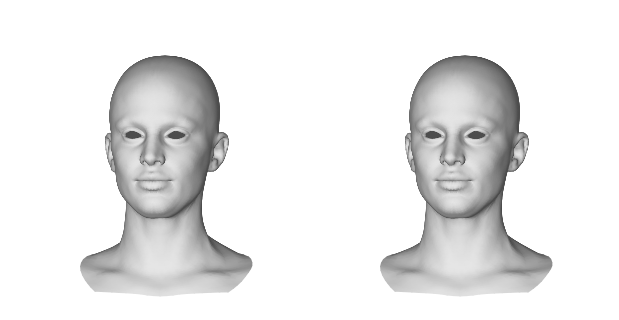

In [52]:
data_name_list = ['voca','biwi','mf_SEN','coma','mf_ROM','ict','ict-cap'] # 0 1 2 3 4 5

SRC_SELECT_DATA=6
SRC_SELECT_MESH=2
EXP_NUM=0

TGT_SELECT_DATA=6
TGT_SELECT_mesh=2

src_selection = data_name_list[SRC_SELECT_DATA]
tgt_selection = data_name_list[TGT_SELECT_DATA]

device='cuda:0'

src_dataset = EvalDataset(data_name=src_selection, toggle=False) # if eve-s01
src_v, src_f = get_mesh(src_selection, src_dataset, SRC_SELECT_MESH)
src_n = igl.per_vertex_normals(src_v, src_f)

tgt_dataset = EvalDataset(data_name=tgt_selection, toggle=False) # if eve-s01
tgt_v, tgt_f = get_mesh(tgt_selection, tgt_dataset, TGT_SELECT_mesh)
tgt_n = igl.per_vertex_normals(tgt_v, tgt_f)

M_SCALE = 0.5
print(src_v.shape, tgt_v.shape)
v_list=[ src_v, tgt_v ]
f_list=[ src_f, tgt_f ]
SIZE=3
rot_list=[[0,-10,0]]

plot_mesh_gouraud(v_list, f_list, mesh_scale=M_SCALE,
        rot_list=rot_list*len(v_list), size=SIZE, mode='shade', bg_black=False)

# v_list=[v * M_SCALE for v in v_list]
# rot_list=[[0,-10,0]]
# plot_image_array(
#     v_list, f_list,
#     rot_list=rot_list*len(v_list), 
#     size=SIZE, bg_black=False, mode='shade', save=True,
#     logdir=f"fig/", name=f"{file_name}-id_{TGT_SELECT_mesh:02d}-neutral", 
# )

In [54]:
#######################################################
ckpt_path = '2025-10-09-02-04-49-NGBCv5'
# ckpt_path = '2025-10-09-02-04-49-NGBCv5_'
# ckpt_path = '2025-09-29-14-48-17-NGBCv8'
# ckpt_path = '2025-09-27-12-04-29-NGBCv5'
# ckpt_path = '2025-09-27-08-05-11-NGBCv5'
if src_selection == 'ict-cap':
    file_name = f'{src_selection}-ID_{SRC_SELECT_MESH:03d}_test-to-{tgt_selection}-ID_{TGT_SELECT_mesh:03d}_test_{EXP_NUM:02d}'
else:
    file_name = f'{src_selection}_test-to-{tgt_selection}_test'
# file_name = f'{src_selection}_test-to-{tgt_selection}_val'
# file_name = f'{src_selection}_test-to-{tgt_selection}_train'
#######################################################

a2b_retarget_path = __abs_path__ + '/eval_CBD/'+ckpt_path+'/'+file_name
print(a2b_retarget_path)
mesh_file_paths = sorted(glob(a2b_retarget_path+'/*.npy'))
len_mesh_file_paths=len(mesh_file_paths)
print(len_mesh_file_paths)

a2b_retarget_path = __abs_path__ + '/eval_CBD/nfr/'+file_name
print(a2b_retarget_path)
nfr_mesh_file_paths = sorted(glob(a2b_retarget_path+'/*.npy'))
len_nfr_mesh_file_paths=len(nfr_mesh_file_paths)
print(len_nfr_mesh_file_paths)

a2b_retarget_path = __abs_path__ + '/eval_CBD/nfs/'+file_name
print(a2b_retarget_path)
nfs_mesh_file_paths = sorted(glob(a2b_retarget_path+'/*.npy'))
len_nfs_mesh_file_paths=len(nfs_mesh_file_paths)
print(len_nfs_mesh_file_paths)

if src_selection == 'ict-cap':
    GT_a2b_retarget_path = __abs_path__ + '/eval_CBD/GT-'+f'{src_selection}_test-to-{src_selection}_test_{EXP_NUM:02d}'
else:
    GT_a2b_retarget_path = __abs_path__ + '/eval_CBD/GT-'+f'{src_selection}_test-to-{src_selection}_test'
    
print(GT_a2b_retarget_path)
GT_mesh_file_paths = sorted(glob(GT_a2b_retarget_path+'/*.npy'))
GT_len_mesh_file_paths=len(GT_mesh_file_paths)
print(GT_len_mesh_file_paths)

/source/sihun/NeuralFacialAnimation/eval_CBD/2025-10-09-02-04-49-NGBCv5/ict-cap-ID_002_test-to-ict-cap-ID_002_test_00
183
/source/sihun/NeuralFacialAnimation/eval_CBD/nfr/ict-cap-ID_002_test-to-ict-cap-ID_002_test_00
183
/source/sihun/NeuralFacialAnimation/eval_CBD/nfs/ict-cap-ID_002_test-to-ict-cap-ID_002_test_00
183
/source/sihun/NeuralFacialAnimation/eval_CBD/GT-ict-cap_test-to-ict-cap_test_00
183


In [55]:
SAVE=0
SIZE=5
button=False
# rot_list=[[0,0,0]]
M_SCALE=0.6
M_SCALE_zoom=1.5
# M_TRANS_zoom=np.array([0,0.5,0])
M_TRANS_zoom=np.array([0,0.52,0])

def update_frame(frame, y_rot, save):
    global button
    plt.close()
    rot_list=[[0,y_rot,0]]
    _ours_= np.load(mesh_file_paths[frame]).squeeze()
    _nfr_= np.load(nfr_mesh_file_paths[frame]).squeeze()
    _nfs_= np.load(nfs_mesh_file_paths[frame]).squeeze()
    _GT_= np.load(GT_mesh_file_paths[frame]).squeeze()
    
    # v_list = [src_v, _GT_, _ours_, _nfr_]
    # v_list = [src_v, _GT_, tgt_v, _ours_, _nfs_, _nfr_]
    v_list =[_GT_]
    # v_list = [_GT_, _ours_, _nfs_, _nfr_] # mf_test-to-mf_test
    v_list += [_ours_, _nfs_, _nfr_] # mf_test-to-mf_test
    # v_list = [tgt_v, _ours_, _nfs_, _nfr_] # mf_test-to-mf_train
    
    f_list = [src_f]
    f_list += [tgt_f]*(len(v_list)-1)
    
    v_list1=[v * M_SCALE for v in v_list]
    plot_image_array(
        v_list1, f_list,
        rot_list=rot_list*len(v_list), 
        size=SIZE, bg_black=False, mode='shade', save=False
    )
    
    v_list2=[v * M_SCALE_zoom +M_TRANS_zoom for v in v_list]
    plot_image_array(
        v_list2, f_list,
        rot_list=rot_list*len(v_list), 
        size=SIZE, bg_black=False, mode='shade', save=False
    )
    if save!=button:
        plot_image_array(
            v_list1, f_list,
            rot_list=rot_list*len(v_list), 
            size=SIZE, bg_black=False, mode='shade', 
            logdir=f"fig/", 
            name=f"{file_name}-{frame:05d}", 
            save=True
        )
        plot_image_array(
            v_list2, f_list,
            rot_list=rot_list*len(v_list), 
            size=SIZE, bg_black=False, mode='shade', 
            logdir=f"fig/", 
            name=f"{file_name}-{frame:05d}-zoom", 
            save=True
        )
        button=save
        print('cl')
    #     save=False

    # def on_click(change):
    #     print('clicked')
     
    # save.observe(on_click, 'value')

    # plot_mesh_gouraud(
    #     v_list, f_list, mesh_scale=M_SCALE, 
    #     # is_diff=True, 
    #     # diff_base=src_v, # calculates difference based on this mesh
    #     diff_base=_GT_, # calculates difference based on this mesh
    #     rot_list=rot_list*len(v_list), size=SIZE, mode='shade', bg_black=False)

sliders = {
    'frame': widgets.IntSlider(value=0, min=0, max=len_mesh_file_paths-1, step=1),
    'y_rot': widgets.FloatSlider(value=0, min=-180, max=180, step=.1),
    'save': widgets.ToggleButton(
        value=False,
        description='save',
        disabled=False,
        button_style='', # 'success', 'info', 'warning', 'danger' or ''
        tooltip='Description',
        icon='check' # (FontAwesome names without the `fa-` prefix)
    )
}
# widgets.interactive(update_frame, frame=slider)
widgets.interact(update_frame, **sliders)

interactive(children=(IntSlider(value=0, description='frame', max=182), FloatSlider(value=0.0, description='y_…

<function __main__.update_frame(frame, y_rot, save)>

# test

In [ ]:
import numpy as np
from utils.exp_utils import PCA_holder
import pickle
import os
from glob import glob

import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib import rc
from sklearn.decomposition import PCA
from ipywidgets import interact, FloatSlider
import matplotlib.tri as mtri

In [ ]:

# ---------- Plot Function ----------
SIZE= 5
def plot_pca_shape(**kwargs):
    # PC0 ~ PC19
    #keys = sorted(kwargs.keys(), key=lambda k: int(k[2:]))
    keys = sorted(list(kwargs.keys()))[:-1]
    visible_coeffs = np.array([kwargs[k] for k in keys])

    # 전체 100차원 중 visible 부분만 채우고 나머지는 0으로
    full_coeffs = np.zeros((1, n_components))
    full_coeffs[0, :n_slider] = visible_coeffs 
    full_coeffs = full_coeffs * np.sqrt(pca_holder.explained_variance_)
    
    model = yrotate(-kwargs["y_rot"])
    view  = translate(0, 0, -3.5)
    proj  = perspective(55, 1, 1, 100)
    MVP   = proj @ view @ model

    V_flat = pca_holder.inverse_transform(full_coeffs)
    print(V_flat.shape, V_flat.min(0), V_flat.max(0))
    
    V = V_flat.reshape(-1, 3)
    V = normalize_homogeneous(V)
    V = V @ MVP.T
    V /= V[:, 3].reshape(-1, 1)

    VF = V[faces]
    T = VF[:, :, :2]
    Z = -VF[:, :, 2].mean(axis=1)
    Z = (Z - Z.min()) / ((Z.max() - Z.min())+1e-12)
    C = plt.get_cmap("magma")(Z)
    I = np.argsort(Z)

    T, C = T[I, :], C[I, :]
    fig = plt.figure(figsize=(SIZE, SIZE))
    ax = fig.add_axes([0, 0, 1, 1], xlim=[-1, 1], ylim=[-1, 1], aspect=1, frameon=False)
    collection = PolyCollection(T, closed=True, linewidth=0.1, facecolor=C, edgecolor="black")
    ax.add_collection(collection)
    plt.show()

# ===== 슬라이더 구성 (PC0~PC19) =====
sliders = {
    f"PC{i}": FloatSlider(value=0.0, min=-3.0, max=3.0, step=0.1, layout={"width": "300px"})
    for i in range(n_slider)
}
sliders["y_rot"]=FloatSlider(value=0.0, min=-90, max=90, step=0.1, layout={"width": "300px"})

interact(plot_pca_shape, **sliders)

print(LST[NUM])
print('123')